# NB7 — Deep Analysis (All Model Groups)
Analyses **three** model groups from the shared `results_cache`:
1. **Vanilla** reference (Qwen3-14B-vanilla)
2. **Perplexity** models (CPT+SFT with PPL filtering)
3. **NoPPL** models (CPT+SFT without PPL filtering)

In [1]:
# ======================================================================
# COLAB BOOTSTRAP — NB7 Deep Analysis (All Model Groups)
# ======================================================================
import os, sys

def _on_colab():
    try:
        import google.colab
        return True
    except Exception:
        return False

if _on_colab():
    REPO_DIR = os.environ.get("FRMEDQA_BASE", "/content/drive/MyDrive/00_PHD_THESIS/frmedqa-colab-v2")
    BASE_DIR = os.environ.get("FRMEDQA_BASE", "/content/drive/MyDrive/00_PHD_THESIS/frmedqa-colab-v2")

    os.system("pip install -q seaborn statsmodels")

    from google.colab import drive
    drive.mount("/content/drive")
    sys.path.insert(0, REPO_DIR)
    os.environ["FRMEDQA_REPO"] = REPO_DIR
    os.environ["FRMEDQA_BASE"] = BASE_DIR
    os.environ["FRMEDQA_PROJECT_NAME"] = "FrMedQA-CrossLingual-v2-PPL"
if os.environ.get("FRMEDQA_SEED"):   # cluster multi-seed run: one HF namespace per seed
    os.environ["FRMEDQA_PROJECT_NAME"] += f"-s{os.environ['FRMEDQA_SEED']}"
    os.environ["FRMEDQA_HF_USER"] = "boods"
    print("Colab bootstrap done | Analysis: Vanilla vs Perplexity vs NoPPL")
else:
    print("Not on Colab.")


Mounted at /content/drive
Colab bootstrap done | Analysis: Vanilla vs Perplexity vs NoPPL


## 🔒 Three-way comparison restriction
Below only three groups are compared: **Qwen3-14B-vanilla**, **Perplexity-\***, **NoPPL-\***. Everything else is ignored.

In [2]:
# ═══════════════════════════════════════════════════════════════════════════
# THREE-WAY COMPARISON RESTRICTION
# From here on we compare ONLY three model groups:
#   1. Vanilla reference    → Qwen3-14B-vanilla
#   2. Perplexity pipeline  → Perplexity-{DAPT,MCQA,ExtQA,AbsQA,Unified}
#   3. NoPPL pipeline       → NoPPL-{DAPT,MCQA,ExtQA,AbsQA,Unified}
# All other cached models are IGNORED in this analysis.
# ═══════════════════════════════════════════════════════════════════════════
VANILLA_REF        = "Qwen3-14B-vanilla"
REF                = VANILLA_REF
PERPLEXITY_MODELS  = ["Perplexity-DAPT","Perplexity-MCQA","Perplexity-ExtQA",
                      "Perplexity-AbsQA","Perplexity-Unified"]
NOPPL_MODELS       = ["NoPPL-DAPT","NoPPL-MCQA","NoPPL-ExtQA",
                      "NoPPL-AbsQA","NoPPL-Unified"]
VANILLA_MODELS     = [VANILLA_REF]
CANDIDATES         = PERPLEXITY_MODELS + NOPPL_MODELS
ALL_KEEP           = VANILLA_MODELS + CANDIDATES

def model_group(name):
    if name is None: return "?"
    if name == VANILLA_REF:              return "vanilla"
    if name.startswith("Perplexity-"):   return "perplexity"
    if name.startswith("NoPPL-"):        return "noppl"
    return "excluded"

GROUP_STYLE = {
    "vanilla":    dict(color="white",     hatch="//",  edgecolor="black"),
    "perplexity": dict(color="lightgray", hatch="",    edgecolor="black"),
    "noppl":      dict(color="0.55",      hatch="xx",  edgecolor="black"),
}

print(f"Three-way comparison restricted to {len(ALL_KEEP)} models:")
for m in ALL_KEEP:
    print(f"  [{model_group(m):10s}] {m}")


Three-way comparison restricted to 11 models:
  [vanilla   ] Qwen3-14B-vanilla
  [perplexity] Perplexity-DAPT
  [perplexity] Perplexity-MCQA
  [perplexity] Perplexity-ExtQA
  [perplexity] Perplexity-AbsQA
  [perplexity] Perplexity-Unified
  [noppl     ] NoPPL-DAPT
  [noppl     ] NoPPL-MCQA
  [noppl     ] NoPPL-ExtQA
  [noppl     ] NoPPL-AbsQA
  [noppl     ] NoPPL-Unified


## 🧹 Fresh start — clear old figures
Wipes `analysis_output/figures/` so this run's outputs aren't mixed with stale ones.

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# 🧹 Reset figures folder — delete all previously generated images so this
# notebook only shows freshly produced figures for the three-way comparison.
# ═══════════════════════════════════════════════════════════════════════════
import os, glob, shutil
# The figures folder is shared by NB7 → NB8 → NB9 → NB10, so it is cleared
# ONCE, at the start of the chain (NB7). Downstream notebooks keep it False
# so they don't delete the figures produced upstream.
RESET_FIGURES = True
if RESET_FIGURES and os.path.isdir(FIG_DIR):
    _removed = 0
    for _f in glob.glob(os.path.join(FIG_DIR, "*")):
        try:
            if os.path.isfile(_f) or os.path.islink(_f):
                os.remove(_f); _removed += 1
            elif os.path.isdir(_f):
                shutil.rmtree(_f); _removed += 1
        except Exception as _e:
            print(f"  could not remove {_f}: {_e}")
    print(f"  ✓ cleared {_removed} item(s) from {FIG_DIR}")
os.makedirs(FIG_DIR, exist_ok=True)
if not RESET_FIGURES:
    print(f"  figures folder kept (RESET_FIGURES=False): {FIG_DIR}")


## ⚙️ Stage 0 — Install

In [3]:
import subprocess, sys, importlib

REQUIRED = {"matplotlib":"matplotlib", "seaborn":"seaborn", "pandas":"pandas",
            "numpy":"numpy", "scipy":"scipy", "sklearn":"scikit-learn",
            "tqdm":"tqdm"}
missing = [pkg for mod, pkg in REQUIRED.items() if importlib.util.find_spec(mod) is None]
if missing:
    raise RuntimeError("Missing package(s) — activate the Poetry env and run `poetry install` (or `poetry add <pkg>`), then restart the kernel.")
print("✓ Stage 0 done")

✓ Stage 0 done


## 🔇 Stage 0+ — Suppress noisy deprecation/info messages

In [4]:
import warnings, logging
for _msg in [r".*attention mask API.*", r".*AttentionMaskConverter.*",
             r".*modeling_attn_mask_utils.*", r".*FixedFormatter.*",
             r".*FixedLocator.*", r".*Glyph .* missing from current font.*"]:
    warnings.filterwarnings("ignore", message=_msg)
for _name in ["transformers.modeling_attn_mask_utils",
              "transformers.masking_utils", "matplotlib", "matplotlib.font_manager"]:
    logging.getLogger(_name).setLevel(logging.ERROR)
print("✓ Stage 0+ done")

✓ Stage 0+ done


## 🔑 Stage 1 — Paths + Drive-safe logger (self-contained)

In [5]:
import os, sys, time, json, datetime

# ─── User-editable paths (default match boods's project layout) ───
BASE_DIR       = os.environ.get("FRMEDQA_BASE", os.path.expanduser("~/frmedqa_experiments"))
EVAL_CACHE_DIR = os.path.join(BASE_DIR, "EVALS", "results_cache")
JUDGE_OUT      = os.path.join(BASE_DIR, "EVALS", "gemma_judge_scores.json")
RESULTS_DIR    = os.path.join(BASE_DIR, "RESULT")
FIG_DIR        = os.path.join(RESULTS_DIR, "figures_deep")
EVALS_DIR      = os.path.join(BASE_DIR, "EVALS")
TEST_PATH      = os.path.join(RESULTS_DIR, "test.jsonl")

# Mount Drive if needed, robust to FUSE cold-cache delay
if "google.colab" in sys.modules:
    from google.colab import drive
    if not os.path.exists("/content/drive/MyDrive"):
        drive.mount("/content/drive", force_remount=False)

# Wait up to 30s for the cache directory to appear (FUSE warm-up)
for _ in range(30):
    if os.path.exists(EVAL_CACHE_DIR): break
    try: os.listdir(BASE_DIR)
    except Exception: pass
    time.sleep(1)
if not os.path.exists(EVAL_CACHE_DIR):
    if "google.colab" in sys.modules:
        from google.colab import drive
        drive.mount("/content/drive", force_remount=True); time.sleep(3)
if not os.path.exists(EVAL_CACHE_DIR):
    print(f"  BASE_DIR exists  : {os.path.exists(BASE_DIR)}")
    if os.path.exists(BASE_DIR):
        print(f"  BASE_DIR listing : {os.listdir(BASE_DIR)}")
    raise FileNotFoundError(
        f"Cache dir missing: {EVAL_CACHE_DIR}\n"
        f"Edit BASE_DIR above if your dated folder differs."
    )

os.makedirs(FIG_DIR, exist_ok=True)
print(f"  EVAL_CACHE_DIR : {EVAL_CACHE_DIR}  ({len(os.listdir(EVAL_CACHE_DIR))} files)")
print(f"  JUDGE_OUT       : {JUDGE_OUT}  ({'EXISTS' if os.path.exists(JUDGE_OUT) else 'MISSING'})")
print(f"  FIG_DIR        : {FIG_DIR}")

  EVAL_CACHE_DIR : /content/drive/MyDrive/00_PHD_THESIS/frmedqa-colab/EVALS/results_cache  (94 files)
  JUDGE_OUT       : /content/drive/MyDrive/00_PHD_THESIS/frmedqa-colab/EVALS/gemma_judge_scores.json  (EXISTS)
  FIG_DIR        : /content/drive/MyDrive/00_PHD_THESIS/frmedqa-colab/RESULT/figures_deep


In [6]:
# Drive-safe file handler so a long figure-export run survives FUSE drops.
import logging

class DriveSafeFileHandler(logging.FileHandler):
    def __init__(self, primary_path, fallback_path):
        self.fallback_path = fallback_path
        try:
            super().__init__(primary_path, mode="a", encoding="utf-8", delay=False)
        except Exception:
            os.makedirs(os.path.dirname(fallback_path), exist_ok=True)
            super().__init__(fallback_path, mode="a", encoding="utf-8", delay=False)

    def _swap(self):
        try:
            if self.stream is not None:
                try: self.stream.close()
                except Exception: pass
            os.makedirs(os.path.dirname(self.fallback_path), exist_ok=True)
            self.baseFilename = os.path.abspath(self.fallback_path)
            self.stream = open(self.baseFilename, mode="a", encoding="utf-8")
        except Exception:
            self.stream = None

    def emit(self, record):
        try: super().emit(record)
        except OSError:
            self._swap()
            try: super().emit(record)
            except Exception: pass
        except Exception: self.handleError(record)

    def flush(self):
        try:
            if self.stream is not None: self.stream.flush()
        except OSError: self._swap()


def now_ts():
    return datetime.datetime.now().strftime("%Y%m%d_%H%M%S")


ts = now_ts()
primary_log  = os.path.join(EVALS_DIR, f"nb7_deep_{ts}.log")
fallback_log = os.path.join(os.environ.get("FRMEDQA_TMP", "/content"), f"nb7_deep_{ts}.log")

logger = logging.getLogger("nb7"); logger.setLevel(logging.INFO); logger.handlers.clear()
fh = DriveSafeFileHandler(primary_log, fallback_log)
fh.setFormatter(logging.Formatter("%(asctime)s | %(levelname).1s | %(message)s",
                                   datefmt="%H:%M:%S"))
ch = logging.StreamHandler()
ch.setFormatter(logging.Formatter("%(asctime)s | %(levelname).1s | %(message)s",
                                   datefmt="%H:%M:%S"))
logger.addHandler(fh); logger.addHandler(ch); logger.propagate = False
logger.info(f"Logger primary  : {primary_log}")


def atomic_write_json(obj, path):
    tmp = path + ".tmp"
    with open(tmp, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2, ensure_ascii=False)
    os.replace(tmp, path)


def load_jsonl(path):
    rows = []
    with open(path, encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line: rows.append(json.loads(line))
    return rows

10:16:27 | I | Logger primary  : /content/drive/MyDrive/00_PHD_THESIS/frmedqa-colab/EVALS/nb7_deep_20260924_101627.log


## 📚 Stage 2 — Load eval cache + Gemma judge into one DataFrame

In [7]:
import pandas as pd
import numpy as np
import re

ALL_TASKS = ["mcqa", "extqa", "absqa"]
PRIMARY_METRIC = {"mcqa":"accuracy", "extqa":"token_f1", "absqa":"judge_composite"}

# ─── Only the three-way comparison models are loaded ───
# (Qwen3-14B-vanilla + Perplexity-* + NoPPL-*; see restriction cell)

# Long-format DF: one row per (model, task, shot, metric)
# Item-level DF: one row per (model, task, shot, item) — needed for paired tests
metric_records = []
item_records   = []

# Helpers for token_f1 / rouge approximation
def _tok(s): return re.findall(r"\b\w+\b", (s or "").lower())

def token_f1(pred, gold):
    p, g = _tok(pred), _tok(gold)
    if not p and not g: return 1.0
    if not p or not g: return 0.0
    common = {}
    for w in p: common[w] = common.get(w,0)+1
    overlap = 0
    for w in g:
        if common.get(w, 0) > 0:
            overlap += 1; common[w] -= 1
    if overlap == 0: return 0.0
    prec = overlap / len(p); rec = overlap / len(g)
    return 2*prec*rec / (prec+rec)


def rouge_l_quick(pred, gold):
    p, g = _tok(pred), _tok(gold)
    if not p or not g: return 0.0
    # LCS length
    m, n = len(p), len(g)
    dp = [[0]*(n+1) for _ in range(m+1)]
    for i in range(m):
        for j in range(n):
            if p[i] == g[j]: dp[i+1][j+1] = dp[i][j] + 1
            else: dp[i+1][j+1] = max(dp[i][j+1], dp[i+1][j])
    lcs = dp[m][n]
    if lcs == 0: return 0.0
    prec = lcs/len(p); rec = lcs/len(g)
    return 2*prec*rec/(prec+rec)


for f in sorted(os.listdir(EVAL_CACHE_DIR)):
    if not f.endswith(".json"): continue
    try:
        d = json.load(open(os.path.join(EVAL_CACHE_DIR, f), encoding="utf-8"))
    except Exception as e:
        logger.warning(f"  skip {f}: {e}"); continue
    model, task, n_shot = d.get("model"), d.get("task"), d.get("n_shot")
    if model not in ALL_KEEP:
        continue   # globally excluded broken / unfair-comparison model
    metrics = d.get("metrics", {}) or {}
    base    = {"model": model, "task": task, "n_shot": n_shot}
    for k, v in metrics.items():
        if k == "bertscore_f1": continue   # explicitly excluded per spec
        if isinstance(v, (int, float)) and not isinstance(v, bool):
            metric_records.append({**base, "metric": k, "value": v})

    # Per-item rows
    for r in d.get("rows", []):
        item = {"model": model, "task": task, "n_shot": n_shot,
                "id": r.get("id"), "gold": r.get("gold","")}
        if task == "mcqa":
            pred = r.get("pred_judged") or r.get("pred", "")
            gold = r.get("gold","") or ""
            item["score"] = float(set(pred.split(",")) == set(gold.split(",")) if pred and gold else 0.0)
        elif task == "extqa":
            item["score"] = token_f1(r.get("pred",""), r.get("gold",""))
        else:
            # ROUGE-L is just a placeholder column for item-level merge,
            # NOT used as the AbsQA primary metric — that's Gemma composite.
            item["score"] = rouge_l_quick(r.get("pred",""), r.get("gold",""))
        item["pred_len"] = len(r.get("pred","") or "")
        item["pred"]     = r.get("pred","") or ""
        item_records.append(item)

df_metrics = pd.DataFrame(metric_records)
df_items   = pd.DataFrame(item_records)
logger.info(f"  metrics rows: {len(df_metrics):,}  | item rows: {len(df_items):,}")
logger.info(f"  models seen : {sorted(df_metrics['model'].unique().tolist())}")

10:17:08 | I |   metrics rows: 315  | item rows: 34,383
10:17:08 | I |   models seen : ['DeepSeek-V3', 'Gemma-3-12B', 'Mistral-7B-Instruct-v0.3', 'NoPPL-AbsQA', 'NoPPL-DAPT', 'NoPPL-ExtQA', 'NoPPL-MCQA', 'NoPPL-Unified', 'Perplexity-AbsQA', 'Perplexity-DAPT', 'Perplexity-ExtQA', 'Perplexity-MCQA', 'Perplexity-Unified', 'Qwen3-14B-vanilla', 'Qwen3-8B']


In [8]:
# Stage 2b — Tag each model
def tag(m):
    """Classify a model name into its group for plotting."""
    if m is None: return "?"
    if isinstance(m, str) and m.startswith("Perplexity-"): return "perplexity"
    if isinstance(m, str) and m.startswith("NoPPL-"):      return "noppl"
    return "vanilla"

# All model groups for comparison
PERPLEXITY_ORDER = ["Perplexity-DAPT","Perplexity-MCQA","Perplexity-ExtQA",
                    "Perplexity-AbsQA","Perplexity-Unified"]
NOPPL_ORDER = ["NoPPL-DAPT","NoPPL-MCQA","NoPPL-ExtQA",
               "NoPPL-AbsQA","NoPPL-Unified"]
VANILLA_ORDER = ["Qwen3-14B-vanilla",]
ALL_MODEL_ORDER = VANILLA_ORDER + PERPLEXITY_ORDER + NOPPL_ORDER

# Color palette for the three groups
GROUP_COLORS = {"vanilla": "#636EFA", "perplexity": "#00CC96", "noppl": "#EF553B"}

In [9]:
# Stage 2c — Load Gemma judge per-row scores AND aggregate to (model, n_shot, axis) means
GEMMA_AXES = ["factual","complete","relevance","safety","composite"]
gemma_per_row  = {}   # (model, n_shot, axis) → {row_id: float}
gemma_means_rec = []  # per (model, n_shot, axis): mean, sem, n

if os.path.exists(JUDGE_OUT):
    judge_data = json.load(open(JUDGE_OUT, encoding="utf-8"))
    logger.info(f"  judge file has {len(judge_data)} entries")

    # Build row-id index by walking the eval cache (we matched by index in NB6 → recover ids here)
    for fname, jr in judge_data.items():
        if jr.get("model") not in ALL_KEEP:
            continue   # only three-way comparison models
        scored = jr.get("scores") or []
        if not scored: continue
        cache_path = os.path.join(EVAL_CACHE_DIR, fname)
        if not os.path.exists(cache_path): continue
        try:
            ev = json.load(open(cache_path, encoding="utf-8"))
        except Exception: continue
        if ev.get("task") != "absqa": continue
        rows = ev.get("rows", [])
        n = min(len(rows), len(scored))
        # collect per-row + per-axis arrays
        per_axis = {a: [] for a in GEMMA_AXES}
        for i in range(n):
            s = scored[i]
            if not s: continue
            for a in GEMMA_AXES:
                v = s.get(a)
                if v is None: continue
                gemma_per_row.setdefault((jr["model"], jr["n_shot"], a), {})[rows[i]["id"]] = float(v)
                per_axis[a].append(float(v))
        # save aggregated means for the metrics dataframe
        for a, vals in per_axis.items():
            if not vals: continue
            mean = float(np.mean(vals))
            sem  = float(np.std(vals, ddof=1) / np.sqrt(len(vals))) if len(vals) > 1 else 0.0
            gemma_means_rec.append({"model": jr["model"], "task": "absqa",
                                    "n_shot": jr["n_shot"],
                                    "metric": f"judge_{a}", "value": mean,
                                    "n": len(vals), "sem": sem})
    if gemma_means_rec:
        df_gem = pd.DataFrame(gemma_means_rec)
        # Inject judge_* into the long metrics frame
        for _, r in df_gem.iterrows():
            df_metrics.loc[len(df_metrics)] = {"model": r["model"], "task": r["task"],
                                                "n_shot": r["n_shot"], "metric": r["metric"],
                                                "value": r["value"], "family": tag(r["model"])}
        logger.info(f"  injected {len(df_gem)} judge_* metric rows")
    logger.info(f"  per-row Gemma keys: {len(gemma_per_row)} (model, n_shot, axis) tuples")
else:
    logger.warning("  Gemma judge file not found — AbsQA will skip Gemma-based plots")

10:17:08 | I |   judge file has 30 entries
10:17:09 | I |   injected 135 judge_* metric rows
10:17:09 | I |   per-row Gemma keys: 135 (model, n_shot, axis) tuples


## 🔁 Stage 3 — Statistical helpers (paired bootstrap, Cohen's d, Cliff's δ)

In [10]:
def paired_bootstrap_delta(scores_a, scores_b, n_boot=10_000, ci=0.95, seed=42):
    """Bootstrap mean(b - a) with paired resampling.
    Returns (mean_delta, ci_low, ci_high, p_two_sided)."""
    rng = np.random.default_rng(seed)
    a = np.asarray(scores_a, dtype=float)
    b = np.asarray(scores_b, dtype=float)
    if len(a) != len(b) or len(a) == 0:
        return (np.nan, np.nan, np.nan, np.nan)
    n = len(a)
    idx = rng.integers(0, n, size=(n_boot, n))
    deltas = (b[idx] - a[idx]).mean(axis=1)
    obs = float((b - a).mean())
    lo  = float(np.quantile(deltas, (1-ci)/2))
    hi  = float(np.quantile(deltas, 1-(1-ci)/2))
    p_left  = (deltas <= 0).mean()
    p_right = (deltas >= 0).mean()
    p = float(2 * min(p_left, p_right))
    return (obs, lo, hi, p)


def cohens_d_paired(a, b):
    a = np.asarray(a, dtype=float); b = np.asarray(b, dtype=float)
    if len(a) == 0: return 0.0
    diff = b - a
    sd = diff.std(ddof=1) if len(diff) > 1 else 0.0
    return float(diff.mean() / sd) if sd > 0 else 0.0


def cliffs_delta(a, b):
    a = np.asarray(a, dtype=float); b = np.asarray(b, dtype=float)
    if len(a) == 0 or len(b) == 0: return 0.0
    n = len(a) * len(b)
    gt = (b[:, None] > a[None, :]).sum()
    lt = (b[:, None] < a[None, :]).sum()
    return float((gt - lt) / n)


def get_paired_traditional(model_a, model_b, task, n_shot):
    a = df_items[(df_items["model"]==model_a) & (df_items["task"]==task) &
                 (df_items["n_shot"]==n_shot)][["id","score"]]
    b = df_items[(df_items["model"]==model_b) & (df_items["task"]==task) &
                 (df_items["n_shot"]==n_shot)][["id","score"]]
    if a.empty or b.empty: return None, None
    m = a.merge(b, on="id", suffixes=("_a","_b")).dropna()
    if len(m) < 5: return None, None
    return m["score_a"].values, m["score_b"].values


def get_paired_gemma(model_a, model_b, axis, n_shot):
    """Per-row Gemma score arrays inner-joined by row id."""
    da = gemma_per_row.get((model_a, n_shot, axis), {})
    db = gemma_per_row.get((model_b, n_shot, axis), {})
    common = sorted(set(da) & set(db))
    if len(common) < 5: return None, None
    return (np.array([da[i] for i in common]),
            np.array([db[i] for i in common]))


def sig_label(p_bonf):
    if p_bonf is None or (isinstance(p_bonf, float) and np.isnan(p_bonf)): return "n/a"
    if p_bonf < 0.001: return "yes (***)"
    if p_bonf < 0.01:  return "yes (**)"
    if p_bonf < 0.05:  return "yes (*)"
    return "no"

## 🧮 Stage 4 — Build COMPARISONS grid (three-way × task × shot)
Three axes:
- **A**: Qwen3-14B-vanilla → each Perplexity-* model (per task × shot)
- **B**: Qwen3-14B-vanilla → each NoPPL-* model (per task × shot)
- **C**: matched Perplexity-<suffix> → NoPPL-<suffix> (is perplexity filtering worth it?)

Plus, for AbsQA, every candidate vs Qwen3-14B-vanilla on each Gemma dimension.

In [13]:
def _model_tasks(m):
    return set(df_items[df_items["model"] == m]["task"].unique())

# Three-way comparison universe: Qwen3-14B-vanilla vs Perplexity-* vs NoPPL-*
PPL_ORDER   = [m for m in PERPLEXITY_MODELS if m in df_items["model"].unique()]
NOPPL_ORDER = [m for m in NOPPL_MODELS      if m in df_items["model"].unique()]
CANDIDATE_ORDER = PPL_ORDER + NOPPL_ORDER
SHOTS = sorted(df_items["n_shot"].unique().tolist())
logger.info(f"  reference    = {VANILLA_REF}")
logger.info(f"  perplexity   = {PPL_ORDER}")
logger.info(f"  noppl        = {NOPPL_ORDER}")
logger.info(f"  shots        = {SHOTS}")

COMPARISONS = []

# Axis A: Qwen3-14B-vanilla vs each Perplexity-* (per task × shot)
for m_en in PPL_ORDER:
    for task in ALL_TASKS:
        if task not in _model_tasks(m_en): continue
        for shot in SHOTS:
            COMPARISONS.append({"axis":"A_vanilla_vs_ppl", "task":task, "n_shot":shot,
                                "a_model":VANILLA_REF, "b_model":m_en, "metric":"primary"})

# Axis B: Qwen3-14B-vanilla vs each NoPPL-* (per task × shot)
for m_en in NOPPL_ORDER:
    for task in ALL_TASKS:
        if task not in _model_tasks(m_en): continue
        for shot in SHOTS:
            COMPARISONS.append({"axis":"B_vanilla_vs_noppl", "task":task, "n_shot":shot,
                                "a_model":VANILLA_REF, "b_model":m_en, "metric":"primary"})

# Axis C: matched Perplexity-<suf> vs NoPPL-<suf> (per task × shot)
_SUFFIXES = ["DAPT","MCQA","ExtQA","AbsQA","Unified"]
for suf in _SUFFIXES:
    ppl, noppl = f"Perplexity-{suf}", f"NoPPL-{suf}"
    if ppl not in PPL_ORDER or noppl not in NOPPL_ORDER: continue
    common_tasks = _model_tasks(ppl) & _model_tasks(noppl)
    for task in common_tasks:
        for shot in SHOTS:
            COMPARISONS.append({"axis":"C_ppl_vs_noppl", "task":task, "n_shot":shot,
                                "a_model":ppl, "b_model":noppl, "metric":"primary"})

# Per-Gemma-axis on AbsQA — every candidate vs Qwen3-14B-vanilla
for m_en in CANDIDATE_ORDER:
    if "absqa" not in _model_tasks(m_en): continue
    for shot in SHOTS:
        for gaxis in GEMMA_AXES:
            COMPARISONS.append({"axis":"A_gemma_axis", "task":"absqa", "n_shot":shot,
                                "a_model":VANILLA_REF, "b_model":m_en, "metric":gaxis})

# Compute deltas
rows = []
for cmp in COMPARISONS:
    if cmp["metric"] == "primary":
        if cmp["task"] == "absqa":
            a, b = get_paired_gemma(cmp["a_model"], cmp["b_model"], "composite", cmp["n_shot"])
        else:
            a, b = get_paired_traditional(cmp["a_model"], cmp["b_model"], cmp["task"], cmp["n_shot"])
    else:
        a, b = get_paired_gemma(cmp["a_model"], cmp["b_model"], cmp["metric"], cmp["n_shot"])

    if a is None:
        rows.append({**cmp, "n":0, "mean_a":np.nan, "mean_b":np.nan,
                     "delta":np.nan, "ci_lo":np.nan, "ci_hi":np.nan,
                     "p_boot":np.nan, "cohens_d":np.nan, "cliffs_d":np.nan})
        continue
    delta, lo, hi, p = paired_bootstrap_delta(a, b)
    rows.append({**cmp, "n":len(a),
                 "mean_a":float(np.mean(a)), "mean_b":float(np.mean(b)),
                 "delta":delta, "ci_lo":lo, "ci_hi":hi, "p_boot":p,
                 "cohens_d":cohens_d_paired(a, b), "cliffs_d":cliffs_delta(a, b)})

df_cmp = pd.DataFrame(rows)
n_valid = df_cmp["delta"].notna().sum()
df_cmp["p_bonf"] = (df_cmp["p_boot"] * max(1, n_valid)).clip(upper=1.0)
df_cmp["sig_05_bonf"] = df_cmp["p_bonf"] < 0.05
df_cmp.to_csv(os.path.join(RESULTS_DIR, "paired_comparisons.csv"), index=False)
logger.info(f"  built {len(df_cmp)} contrasts ({n_valid} valid) — saved paired_comparisons.csv")
df_cmp.head()


10:17:54 | I |   vanillas=['Qwen3-14B-vanilla']
10:17:54 | I |   enmed   =['EnMed-DAPT', 'EnMed-MCQA', 'EnMed-ExtQA', 'EnMed-AbsQA', 'EnMed-Unified']
10:17:54 | I |   shots   =[0, 3, 5]
10:17:54 | I |   built 18 contrasts (0 valid) — saved paired_comparisons.csv


                   axis  task  n_shot     a_model       b_model  metric  n  mean_a  mean_b  delta  ci_lo  ci_hi  p_boot  cohens_d  cliffs_d  p_bonf  sig_05_bonf
   B_dapt_vs_specialist  mcqa       0  EnMed-DAPT    EnMed-MCQA primary  0     NaN     NaN    NaN    NaN    NaN     NaN       NaN       NaN     NaN        False
   B_dapt_vs_specialist  mcqa       3  EnMed-DAPT    EnMed-MCQA primary  0     NaN     NaN    NaN    NaN    NaN     NaN       NaN       NaN     NaN        False
   B_dapt_vs_specialist  mcqa       5  EnMed-DAPT    EnMed-MCQA primary  0     NaN     NaN    NaN    NaN    NaN     NaN       NaN       NaN     NaN        False
   B_dapt_vs_specialist extqa       0  EnMed-DAPT   EnMed-ExtQA primary  0     NaN     NaN    NaN    NaN    NaN     NaN       NaN       NaN     NaN        False
   B_dapt_vs_specialist extqa       3  EnMed-DAPT   EnMed-ExtQA primary  0     NaN     NaN    NaN    NaN    NaN     NaN       NaN       NaN     NaN        False
   B_dapt_vs_specialist extqa     

## 📈 Stage 5 — Shot-performance curves (AbsQA primary = Gemma composite)

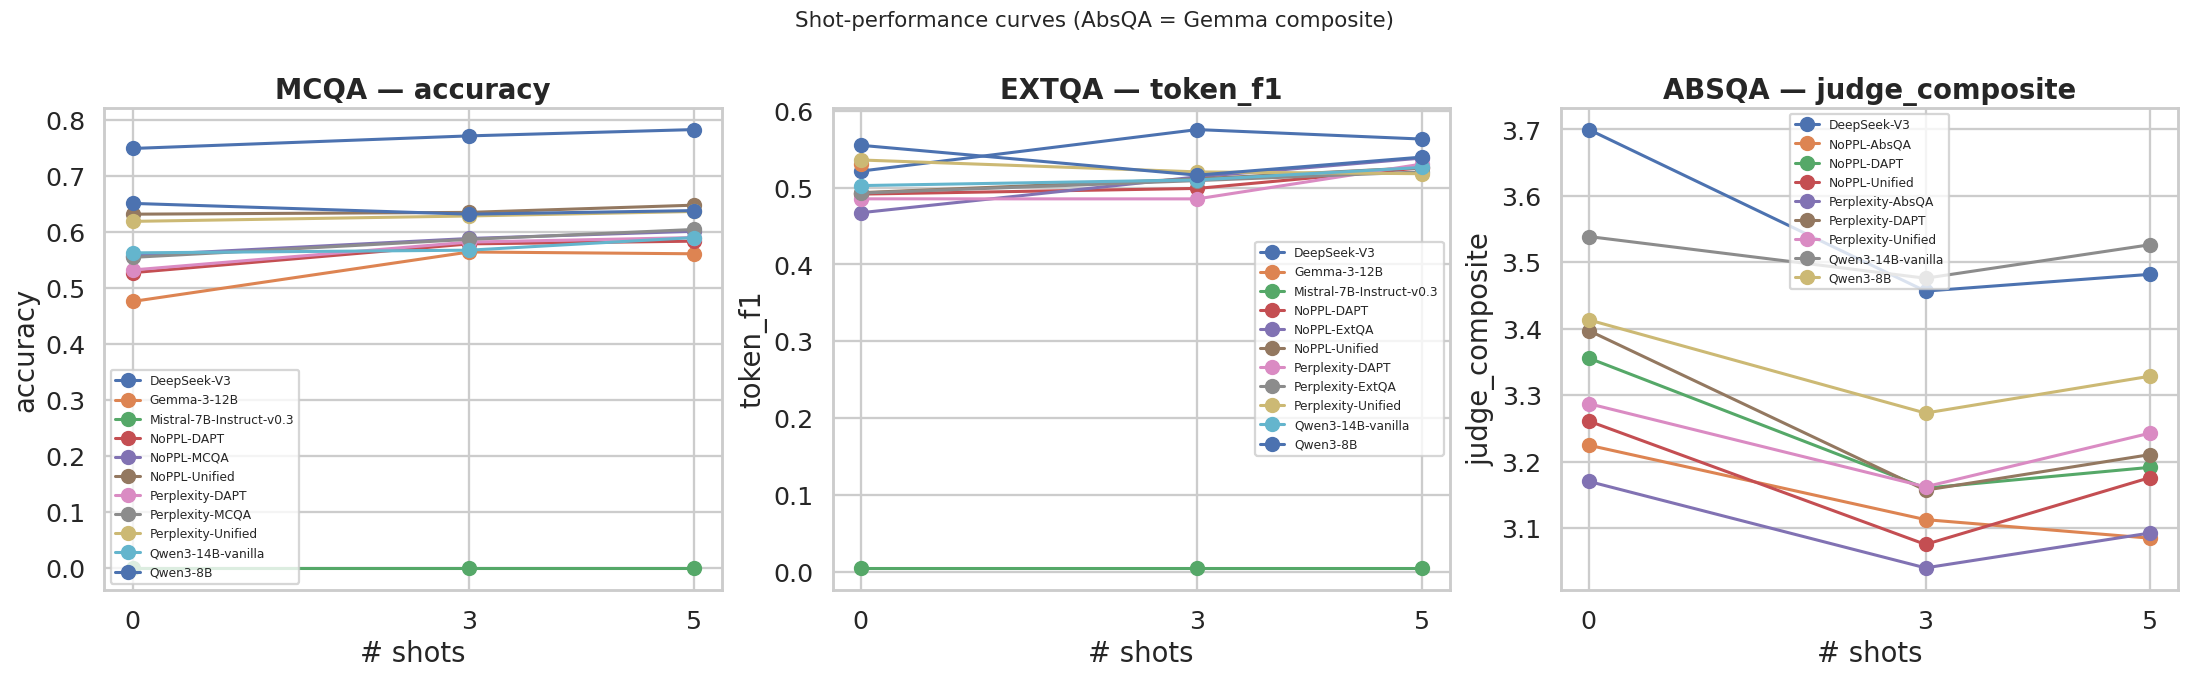

10:18:10 | I | ✓ /content/drive/MyDrive/00_PHD_THESIS/frmedqa-colab/RESULT/figures_deep/fig01_shot_curves.png


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams.update({"savefig.dpi": 200, "figure.dpi": 110,
                     "axes.titleweight":"bold", "font.size": 10})


def primary_for(task, n_shot, df_metrics):
    metric = PRIMARY_METRIC[task]
    return df_metrics[(df_metrics["task"]==task) &
                      (df_metrics["n_shot"]==n_shot) &
                      (df_metrics["metric"]==metric)]


fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for ax, task in zip(axes, ALL_TASKS):
    metric = PRIMARY_METRIC[task]
    sub = df_metrics[(df_metrics["task"]==task) & (df_metrics["metric"]==metric)]
    if sub.empty:
        ax.text(0.5, 0.5, f"{task}: no data", transform=ax.transAxes, ha="center")
        ax.set_title(f"{task.upper()} — {metric}"); continue
    for model, g in sub.groupby("model"):
        g = g.sort_values("n_shot")
        ax.plot(g["n_shot"], g["value"], marker="o", linewidth=2, label=model)
    ax.set_title(f"{task.upper()} — {metric}")
    ax.set_xlabel("# shots"); ax.set_ylabel(metric)
    ax.set_xticks(SHOTS)
    ax.legend(fontsize=8, loc="best")
plt.suptitle("Shot-performance curves (AbsQA = Gemma composite)", fontsize=14, y=1.02)
plt.tight_layout()
out = os.path.join(FIG_DIR, "fig01_shot_curves.png")
plt.savefig(out, bbox_inches="tight"); plt.show()
logger.info(f"✓ {out}")

## 🕸️ Stage 6 — Radar at best-shot per model (Gemma composite for AbsQA)

task                        mcqa   extqa   absqa
model                                           
DeepSeek-V3               0.7830  0.5754  3.6996
Gemma-3-12B               0.5643  0.5302  0.0000
Mistral-7B-Instruct-v0.3  0.0000  0.0048  0.0000
NoPPL-AbsQA               0.0000  0.0000  3.2248
NoPPL-DAPT                0.5836  0.5257  3.3558
NoPPL-ExtQA               0.0000  0.5383  0.0000
NoPPL-MCQA                0.6013  0.0000  0.0000
NoPPL-Unified             0.6479  0.5261  3.2611
Perplexity-AbsQA          0.0000  0.0000  3.1704
Perplexity-DAPT           0.5900  0.5305  3.3972
Perplexity-ExtQA          0.0000  0.5203  0.0000
Perplexity-MCQA           0.6045  0.0000  0.0000
Perplexity-Unified        0.6367  0.5358  3.2873
Qwen3-14B-vanilla         0.5900  0.5261  3.5387
Qwen3-8B                  0.6511  0.5550  3.4133


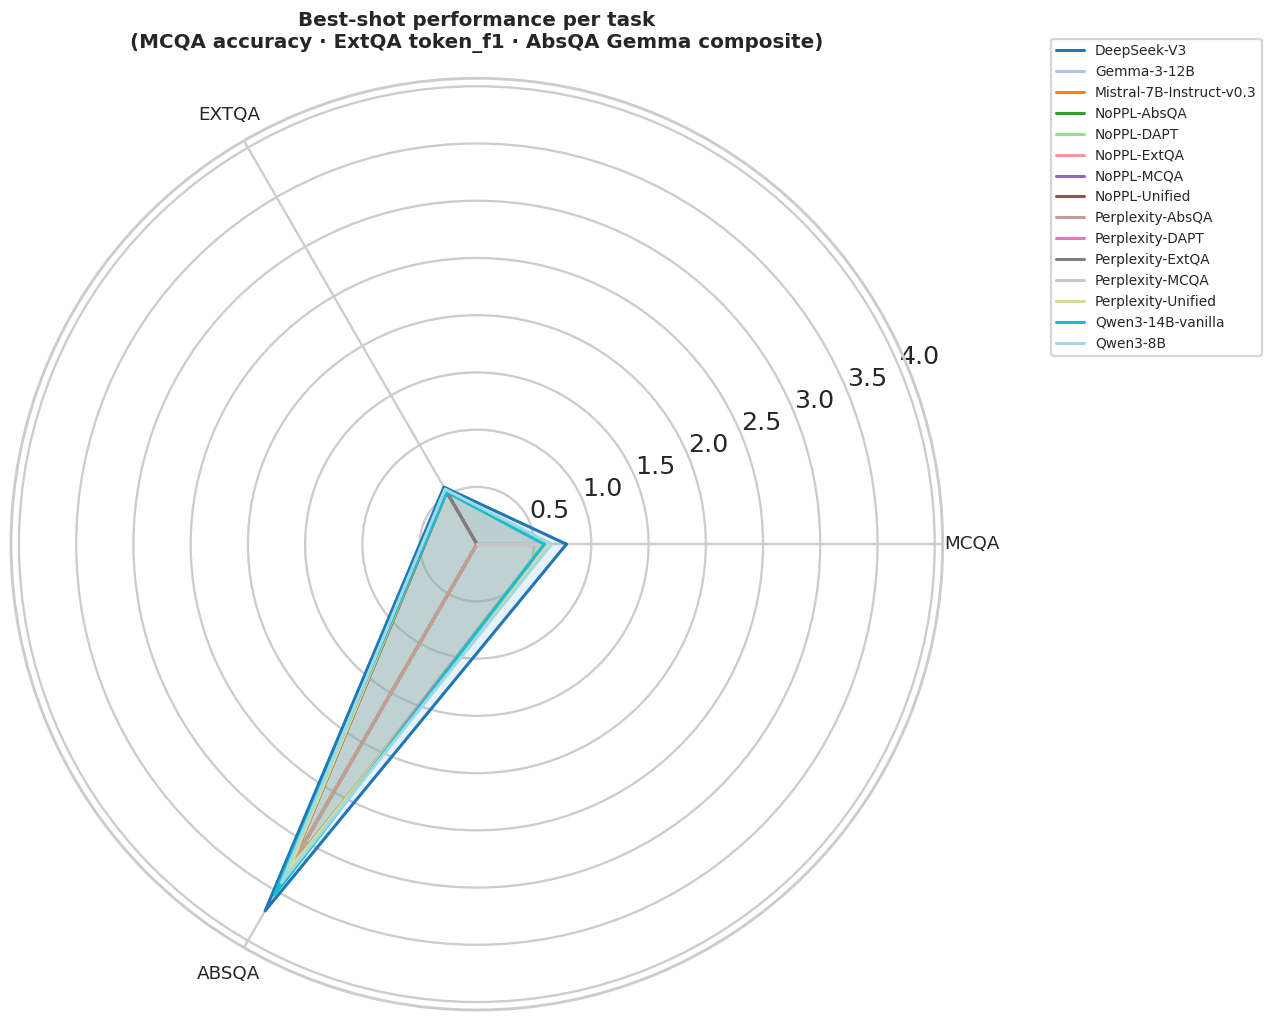

10:18:21 | I | ✓ /content/drive/MyDrive/00_PHD_THESIS/frmedqa-colab/RESULT/figures_deep/fig02_radar_best_shot.png


In [15]:
# Each model takes its best shot per task — picks the highest score
records = []
for (m, t), g in df_metrics.groupby(["model","task"]):
    pm = PRIMARY_METRIC[t]
    gg = g[g["metric"]==pm]
    if gg.empty or gg["value"].dropna().empty: continue
    best = gg.loc[gg["value"].idxmax()]
    records.append({"model":m, "task":t, "best_shot":int(best["n_shot"]),
                    "score":float(best["value"])})
df_best = pd.DataFrame(records)
if df_best.empty:
    logger.warning("  no best-shot data — skipping radar")
else:
    pivot = df_best.pivot(index="model", columns="task", values="score").fillna(0.0)
    # Reorder columns
    cols = [t for t in ALL_TASKS if t in pivot.columns]
    pivot = pivot[cols]
    # Display table
    print(pivot.round(4).to_string())
    pivot.to_csv(os.path.join(RESULTS_DIR, "best_shot_per_task.csv"))

    if len(cols) >= 2:
        angles = np.linspace(0, 2*np.pi, len(cols), endpoint=False).tolist()
        angles += angles[:1]
        fig, ax = plt.subplots(figsize=(11, 11), subplot_kw=dict(polar=True))
        cmap = plt.cm.tab20(np.linspace(0, 1, len(pivot)))
        for (model, row), color in zip(pivot.iterrows(), cmap):
            vals = row.tolist() + [row.tolist()[0]]
            ax.plot(angles, vals, label=model, color=color, linewidth=2)
            ax.fill(angles, vals, alpha=0.10, color=color)
        ax.set_xticks(angles[:-1]); ax.set_xticklabels([t.upper() for t in cols], size=12)
        vmax = max(0.05, float(pivot.values.max())*1.1)
        ax.set_ylim(0, vmax)
        plt.legend(loc="upper right", bbox_to_anchor=(1.35, 1.05), fontsize=9)
        plt.title("Best-shot performance per task\n(MCQA accuracy · ExtQA token_f1 · AbsQA Gemma composite)",
                  pad=20, fontsize=13)
        out = os.path.join(FIG_DIR, "fig02_radar_best_shot.png")
        plt.savefig(out, bbox_inches="tight"); plt.show()
        logger.info(f"✓ {out}")

## 🌲 Stage 7 — Forest plot of headline contrasts

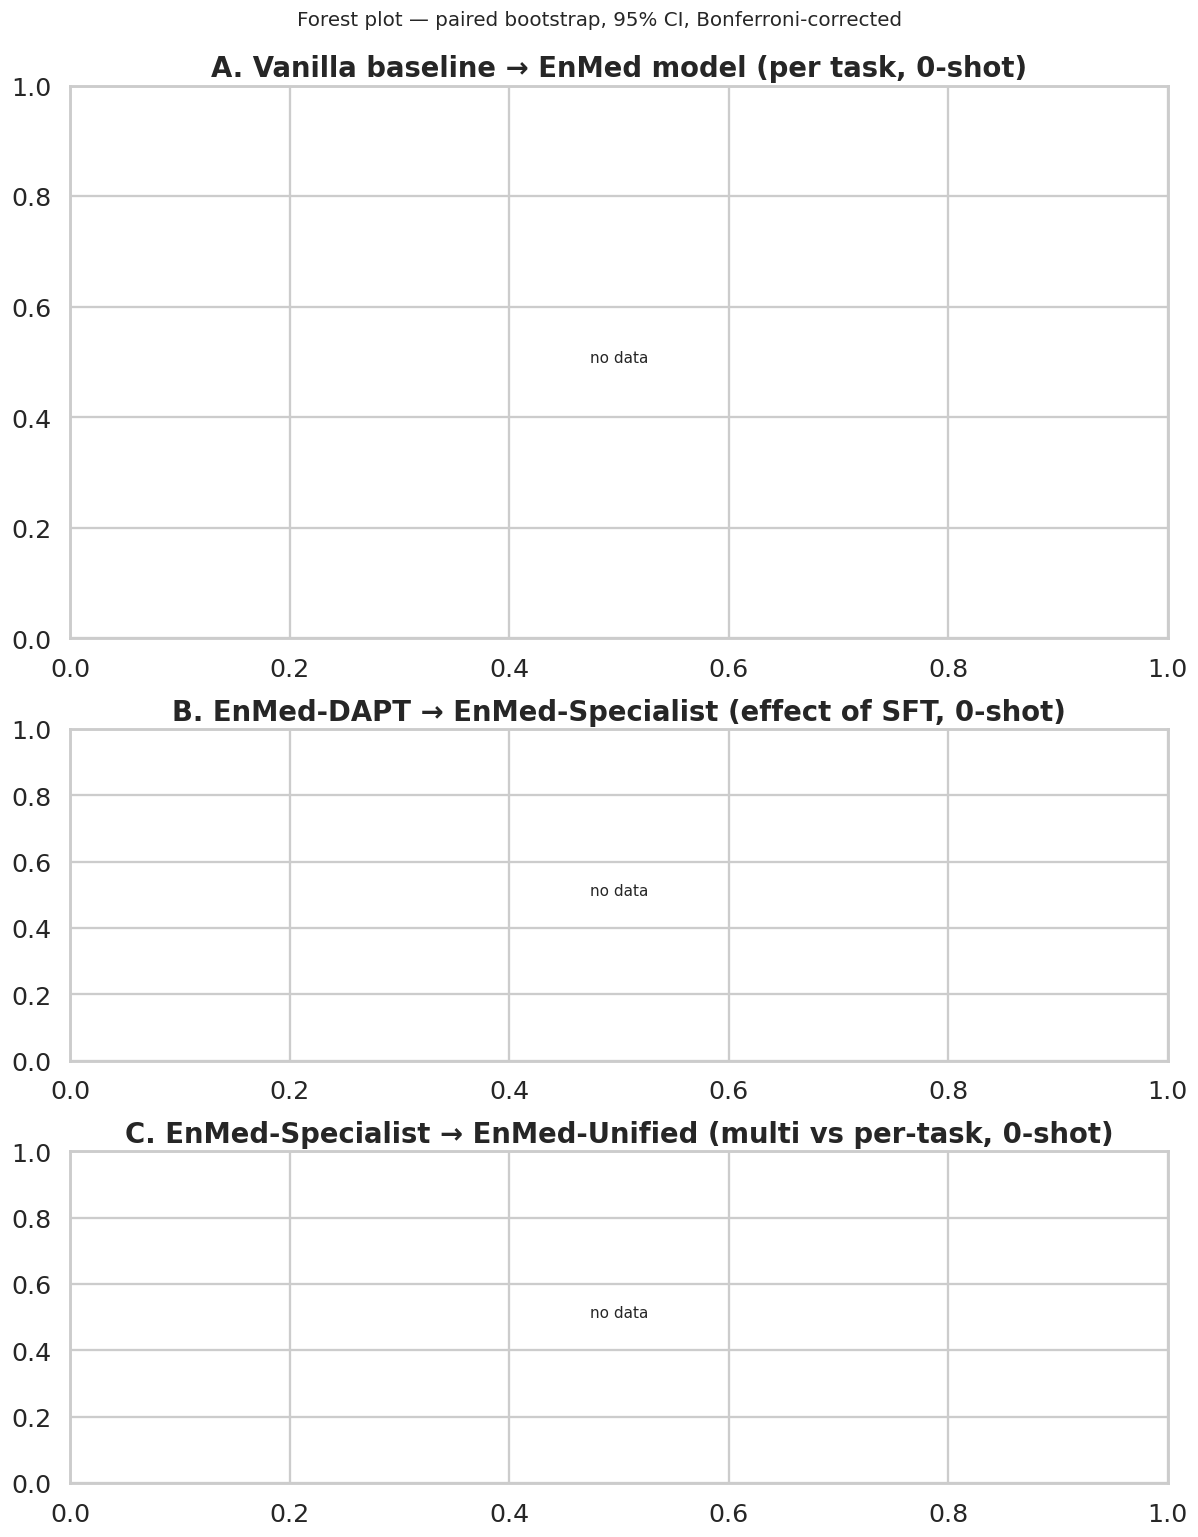

10:18:30 | I | ✓ /content/drive/MyDrive/00_PHD_THESIS/frmedqa-colab/RESULT/figures_deep/fig03_forest_contrasts.png


In [16]:
# Forest plot of A/B/C axes at 0-shot
fig, axes = plt.subplots(3, 1, figsize=(11, 14),
                          gridspec_kw={"height_ratios":[5, 3, 3]})
axis_titles = {
    "A_vanilla_vs_ppl":   "A. Qwen3-14B-vanilla → Perplexity-* (per task, 0-shot)",
    "B_vanilla_vs_noppl": "B. Qwen3-14B-vanilla → NoPPL-* (per task, 0-shot)",
    "C_ppl_vs_noppl":     "C. Perplexity-<suf> → NoPPL-<suf> (matched, 0-shot)",
}

for ax, (axis_key, title) in zip(axes, axis_titles.items()):
    sub = df_cmp[(df_cmp["axis"]==axis_key) & (df_cmp["n_shot"]==0) &
                 (df_cmp["metric"]=="primary")].copy()
    sub = sub.dropna(subset=["delta"])
    if sub.empty:
        ax.set_title(title); ax.text(0.5, 0.5, "no data", transform=ax.transAxes, ha="center")
        continue
    sub["label"] = sub.apply(lambda r: f"{r['task'].upper()}: {r['a_model']} → {r['b_model']}", axis=1)
    sub = sub.sort_values("delta", ascending=True).reset_index(drop=True)
    ys = np.arange(len(sub))
    err_lo = sub["delta"] - sub["ci_lo"]; err_hi = sub["ci_hi"] - sub["delta"]
    colors = ["#2ecc71" if (lo > 0) else ("#e74c3c" if (hi < 0) else "#95a5a6")
              for lo, hi in zip(sub["ci_lo"], sub["ci_hi"])]
    ax.errorbar(sub["delta"], ys, xerr=[err_lo, err_hi],
                fmt="o", capsize=4, ecolor="black", elinewidth=1.2,
                markersize=8, markerfacecolor="white", markeredgecolor="black")
    for y, c, d in zip(ys, colors, sub["delta"]):
        ax.scatter(d, y, color=c, s=80, zorder=5, edgecolor="black", linewidth=0.5)
    ax.axvline(0, color="black", linestyle="--", linewidth=0.8, alpha=0.5)
    ax.set_yticks(ys); ax.set_yticklabels(sub["label"], fontsize=8)
    ax.set_xlabel("Δ (paired b − a)  ·  95% bootstrap CI")
    ax.set_title(title, fontsize=11)
    for y, p, n in zip(ys, sub["p_bonf"], sub["n"]):
        if pd.isna(p): continue
        s = "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else "ns"))
        ax.text(ax.get_xlim()[1]*0.98, y, f"n={n}, p_bonf={p:.2g} {s}",
                ha="right", va="center", fontsize=7, alpha=0.8)
plt.suptitle("Forest plot — paired bootstrap, 95% CI, Bonferroni-corrected", y=0.995, fontsize=13)
plt.tight_layout()
out = os.path.join(FIG_DIR, "fig03_forest_contrasts.png")
plt.savefig(out, bbox_inches="tight"); plt.show()
logger.info(f"✓ {out}")

## ⚔️ Stage 8 — Pairwise win-rate matrices per task **per shot**
Greens colormap throughout. P(row beats column). When a candidate beats Qwen3-14B-vanilla, the cell is deep green; when Qwen3-14B-vanilla wins, the cell is pale.

/tmp/ipykernel_1229/2483467243.py:79: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.97])


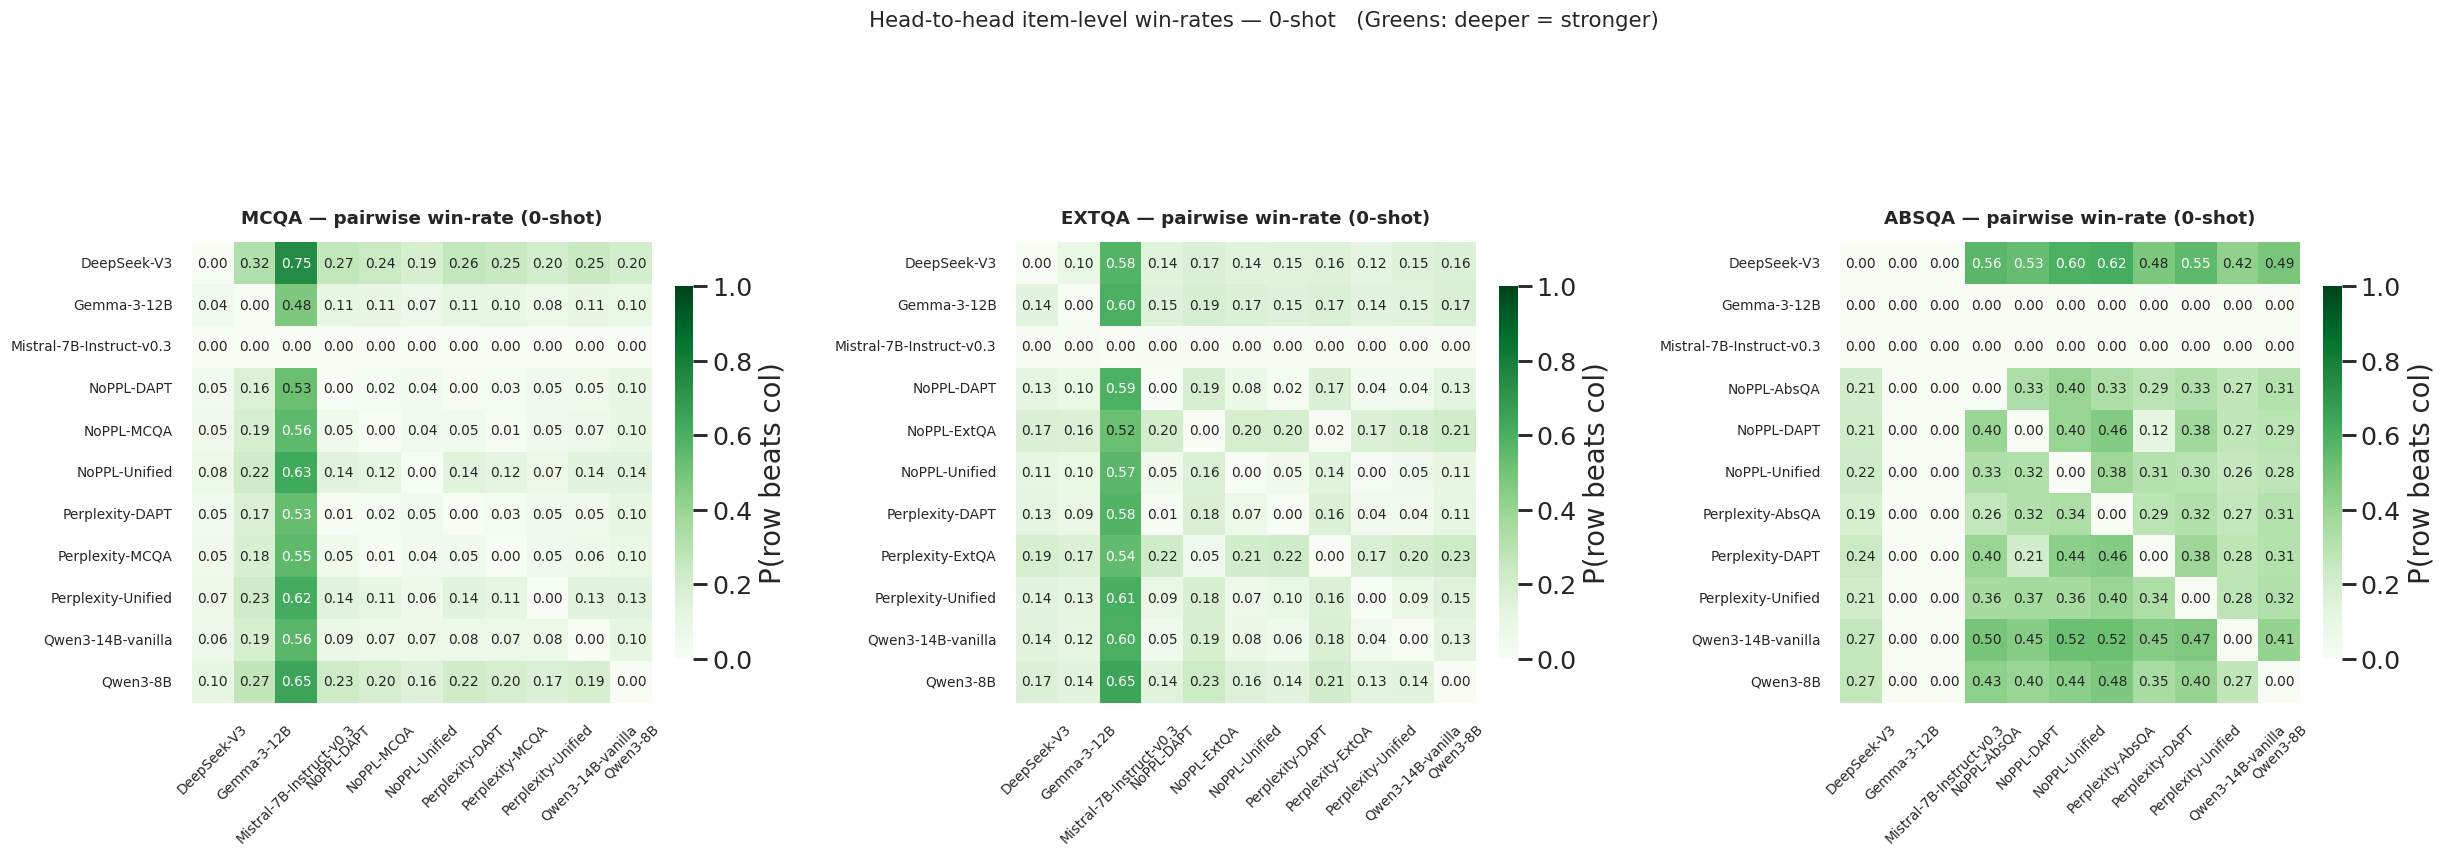

10:18:39 | I | ✓ /content/drive/MyDrive/00_PHD_THESIS/frmedqa-colab/RESULT/figures_deep/fig04_winloss_0shot.png
/tmp/ipykernel_1229/2483467243.py:79: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.97])


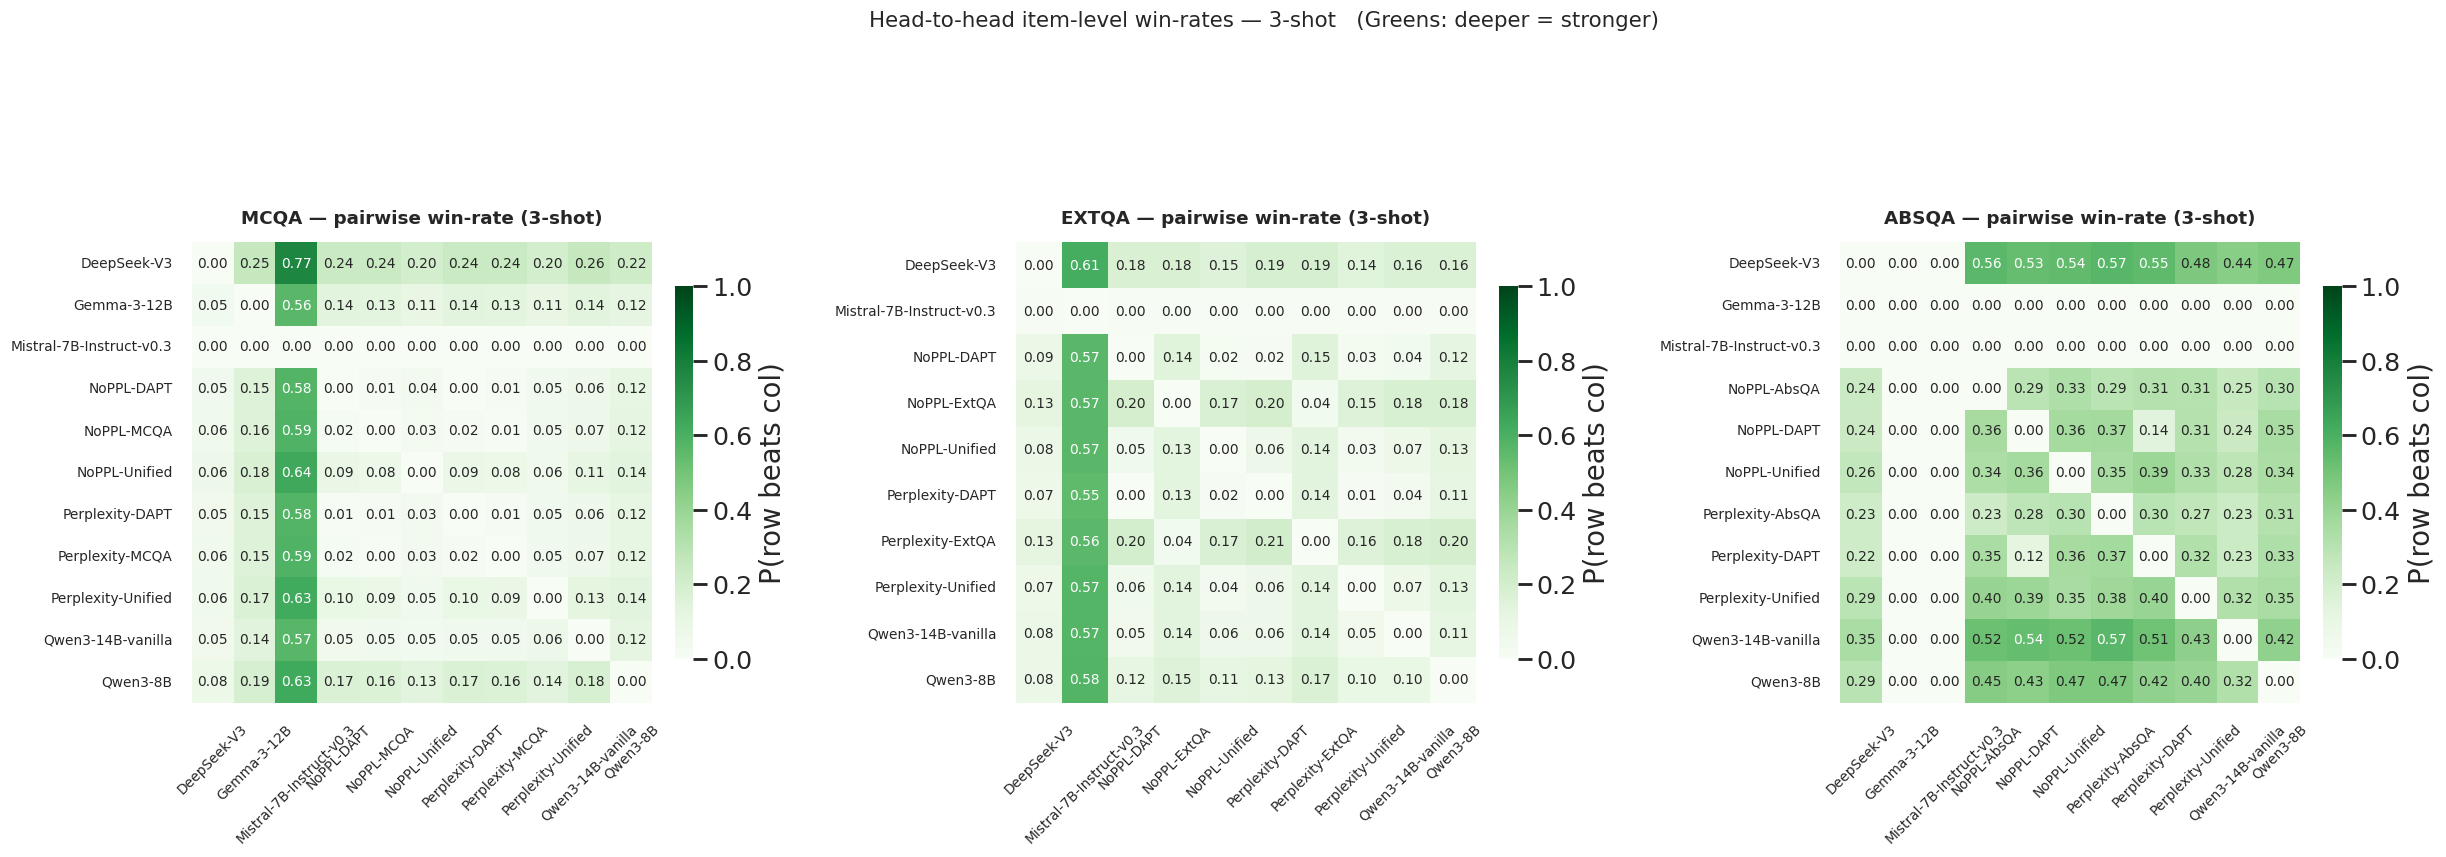

10:18:44 | I | ✓ /content/drive/MyDrive/00_PHD_THESIS/frmedqa-colab/RESULT/figures_deep/fig04_winloss_3shot.png
/tmp/ipykernel_1229/2483467243.py:79: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.97])


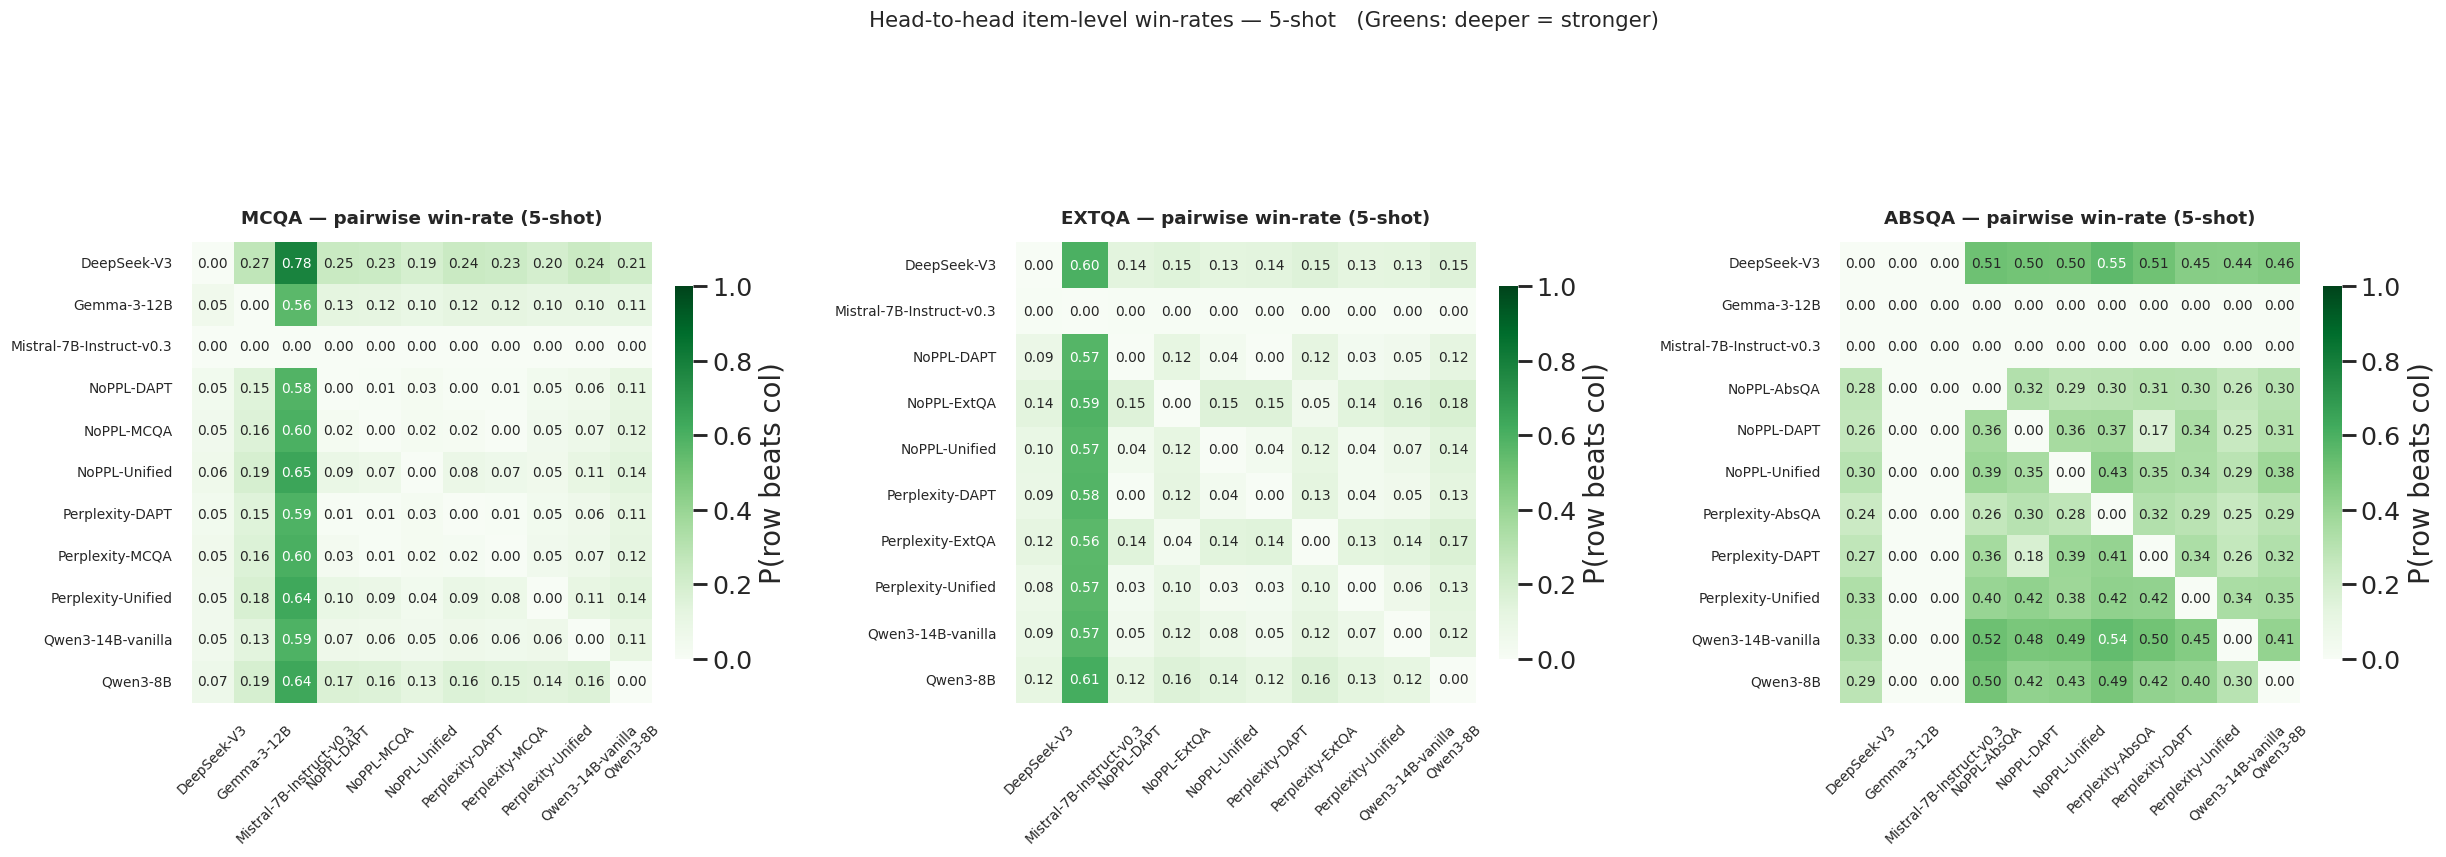

10:18:49 | I | ✓ /content/drive/MyDrive/00_PHD_THESIS/frmedqa-colab/RESULT/figures_deep/fig04_winloss_5shot.png


In [17]:
def winloss_matrix(df_t):
    models = sorted(df_t["model"].unique().tolist())
    n = len(models)
    W = np.zeros((n, n))
    for i, ma in enumerate(models):
        for j, mb in enumerate(models):
            if i == j: continue
            a = df_t[df_t["model"]==ma][["id","score"]]
            b = df_t[df_t["model"]==mb][["id","score"]]
            m = a.merge(b, on="id", suffixes=("_a","_b")).dropna()
            if m.empty: continue
            W[i,j] = (m["score_a"] > m["score_b"]).mean()
    return pd.DataFrame(W, index=models, columns=models)


# AbsQA win-rate uses Gemma composite per row, not the rouge_l_quick placeholder
def winloss_matrix_absqa_gemma():
    models = sorted([m for m in df_items["model"].unique() if "absqa" in _model_tasks(m) or tag(m)=="vanilla"])
    n = len(models)
    W = np.zeros((n, n))
    for i, ma in enumerate(models):
        for j, mb in enumerate(models):
            if i == j: continue
            da = gemma_per_row.get((ma, 0, "composite"), {})
            db = gemma_per_row.get((mb, 0, "composite"), {})
            common = set(da) & set(db)
            if not common: continue
            wins = sum(1 for k in common if da[k] > db[k])
            W[i,j] = wins / len(common)
    return pd.DataFrame(W, index=models, columns=models)


for shot in SHOTS:
    fig, axes = plt.subplots(1, 3, figsize=(26, 8),
                              gridspec_kw={"wspace": 0.45})
    drew = 0
    for ax, task in zip(axes, ALL_TASKS):
        if task == "absqa":
            # Gemma-composite win-rate at this shot (recompute per shot)
            models = sorted([m for m in df_items["model"].unique()
                             if "absqa" in _model_tasks(m) or tag(m)=="vanilla"])
            n = len(models)
            W = np.zeros((n, n))
            valid_any = False
            for i, ma in enumerate(models):
                for j, mb in enumerate(models):
                    if i == j: continue
                    da = gemma_per_row.get((ma, shot, "composite"), {})
                    db = gemma_per_row.get((mb, shot, "composite"), {})
                    common = set(da) & set(db)
                    if not common: continue
                    valid_any = True
                    wins = sum(1 for k in common if da[k] > db[k])
                    W[i,j] = wins / len(common)
            if not valid_any:
                ax.set_visible(False); continue
            W = pd.DataFrame(W, index=models, columns=models)
        else:
            sub = df_items[(df_items["task"]==task) & (df_items["n_shot"]==shot)]
            if sub.empty:
                ax.set_visible(False); continue
            W = winloss_matrix(sub)
        sns.heatmap(W, annot=True, fmt=".2f", cmap="Greens", vmin=0, vmax=1,
                    square=True,
                    cbar_kws={"label":"P(row beats col)", "shrink":0.55, "pad":0.04},
                    ax=ax,
                    annot_kws={"fontsize":9})
        ax.set_title(f"{task.upper()} — pairwise win-rate ({shot}-shot)",
                     fontsize=12, pad=12)
        ax.set_xlabel(""); ax.set_ylabel("")
        ax.tick_params(axis="x", rotation=45, labelsize=9)
        ax.tick_params(axis="y", labelsize=9)
        drew += 1
    if drew == 0:
        plt.close(fig); continue
    fig.suptitle(f"Head-to-head item-level win-rates — {shot}-shot   "
                 f"(Greens: deeper = stronger)",
                 fontsize=14, y=1.02)
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    out = os.path.join(FIG_DIR, f"fig04_winloss_{shot}shot.png")
    plt.savefig(out, bbox_inches="tight"); plt.show()
    logger.info(f"✓ {out}")

## 📐 Stage 9 — Effect-size heatmap per task **per shot**

In [18]:
def effect_size(model_a, model_b, task, n_shot):
    if task == "absqa":
        a, b = get_paired_gemma(model_a, model_b, "composite", n_shot)
    else:
        a, b = get_paired_traditional(model_a, model_b, task, n_shot)
    if a is None: return np.nan
    return cohens_d_paired(a, b)


for shot in SHOTS:
    if not CANDIDATE_ORDER:
        logger.warning(f"  no models for shot={shot} effect-size heatmap"); continue

    fig, axes = plt.subplots(1, 3, figsize=(24, 4.5),
                              gridspec_kw={"wspace": 0.45})
    drew = 0
    for ax, task in zip(axes, ALL_TASKS):
        rows_h = []
        for m_van in [VANILLA_REF]:
            row = []
            for m_en in CANDIDATE_ORDER:
                if task not in _model_tasks(m_en):
                    row.append(np.nan); continue
                row.append(effect_size(m_van, m_en, task, shot))
            rows_h.append(row)
        H = pd.DataFrame(rows_h, index=[VANILLA_REF], columns=CANDIDATE_ORDER)
        if H.isna().all().all():
            ax.set_visible(False); continue
        sns.heatmap(H, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
                    vmin=-1.5, vmax=1.5, ax=ax,
                    cbar_kws={"label":"Cohen's d (candidate − Qwen3-14B)",
                              "shrink":0.55, "pad":0.04},
                    annot_kws={"fontsize":10})
        ax.set_title(f"{task.upper()} — effect size ({shot}-shot)",
                     fontsize=12, pad=12)
        ax.set_xlabel("Perplexity-* | NoPPL-*"); ax.set_ylabel("")
        ax.tick_params(axis="x", rotation=45, labelsize=9)
        ax.tick_params(axis="y", labelsize=9)
        drew += 1
    if drew == 0:
        plt.close(fig); continue
    fig.suptitle(f"Paired effect sizes — {shot}-shot   "
                 f"(positive = candidate beats Qwen3-14B-vanilla)",
                 fontsize=14, y=1.02)
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    out = os.path.join(FIG_DIR, f"fig05_effect_size_{shot}shot.png")
    plt.savefig(out, bbox_inches="tight"); plt.show()
    logger.info(f"✓ {out}")

## 📊 Stage 10 — Per-shot delta (Qwen3-14B-vanilla → Perplexity-Unified / NoPPL-Unified)

In [20]:
# Per-shot Δ curves for the two "Unified" candidates against Qwen3-14B-vanilla
UNIFIED_PAIRS = [("Perplexity-Unified", "perplexity"), ("NoPPL-Unified", "noppl")]
UNIFIED_PAIRS = [(m, g) for (m, g) in UNIFIED_PAIRS if m in df_items["model"].unique()]

panels = []
for task in ALL_TASKS:
    task_rows = []
    for m_cand, group in UNIFIED_PAIRS:
        for s in SHOTS:
            if task == "absqa":
                a, b = get_paired_gemma(VANILLA_REF, m_cand, "composite", s)
            else:
                a, b = get_paired_traditional(VANILLA_REF, m_cand, task, s)
            if a is None: continue
            delta, lo, hi, p = paired_bootstrap_delta(a, b)
            task_rows.append({"shot":s, "candidate":m_cand, "group":group,
                              "delta":delta, "ci_lo":lo, "ci_hi":hi, "p":p})
    if task_rows: panels.append((task, pd.DataFrame(task_rows)))

if not panels:
    logger.warning("  no data for per-shot delta plots — skipping")
else:
    fig, axes = plt.subplots(1, len(panels), figsize=(7*len(panels), 5),
                              squeeze=False)
    for ax, (task, sub) in zip(axes[0], panels):
        for cand, g in sub.groupby("candidate"):
            g = g.sort_values("shot")
            err_lo = g["delta"] - g["ci_lo"]; err_hi = g["ci_hi"] - g["delta"]
            marker = "o" if g["group"].iloc[0] == "perplexity" else "s"
            ax.errorbar(g["shot"], g["delta"], yerr=[err_lo, err_hi],
                        fmt=f"{marker}-", capsize=4, linewidth=2, markersize=9,
                        label=cand)
        ax.axhline(0, color="grey", linestyle="--", alpha=0.5)
        ax.set_xlabel("# few-shot examples")
        ax.set_ylabel(f"Δ (candidate − {VANILLA_REF})")
        ax.set_xticks(SHOTS)
        ax.set_title(task.upper())
        ax.legend(fontsize=8)
    plt.suptitle(f"How does few-shot prompting change the candidate-vs-{VANILLA_REF} gap?",
                 y=1.05, fontsize=13)
    plt.tight_layout()
    out = os.path.join(FIG_DIR, "fig06_per_shot_delta.png")
    plt.savefig(out, bbox_inches="tight"); plt.show()
    logger.info(f"✓ {out}")


10:19:28 | W |   no data for per-shot delta plots — skipping


## ✏️ Stage 11 — Length distribution per task per shot

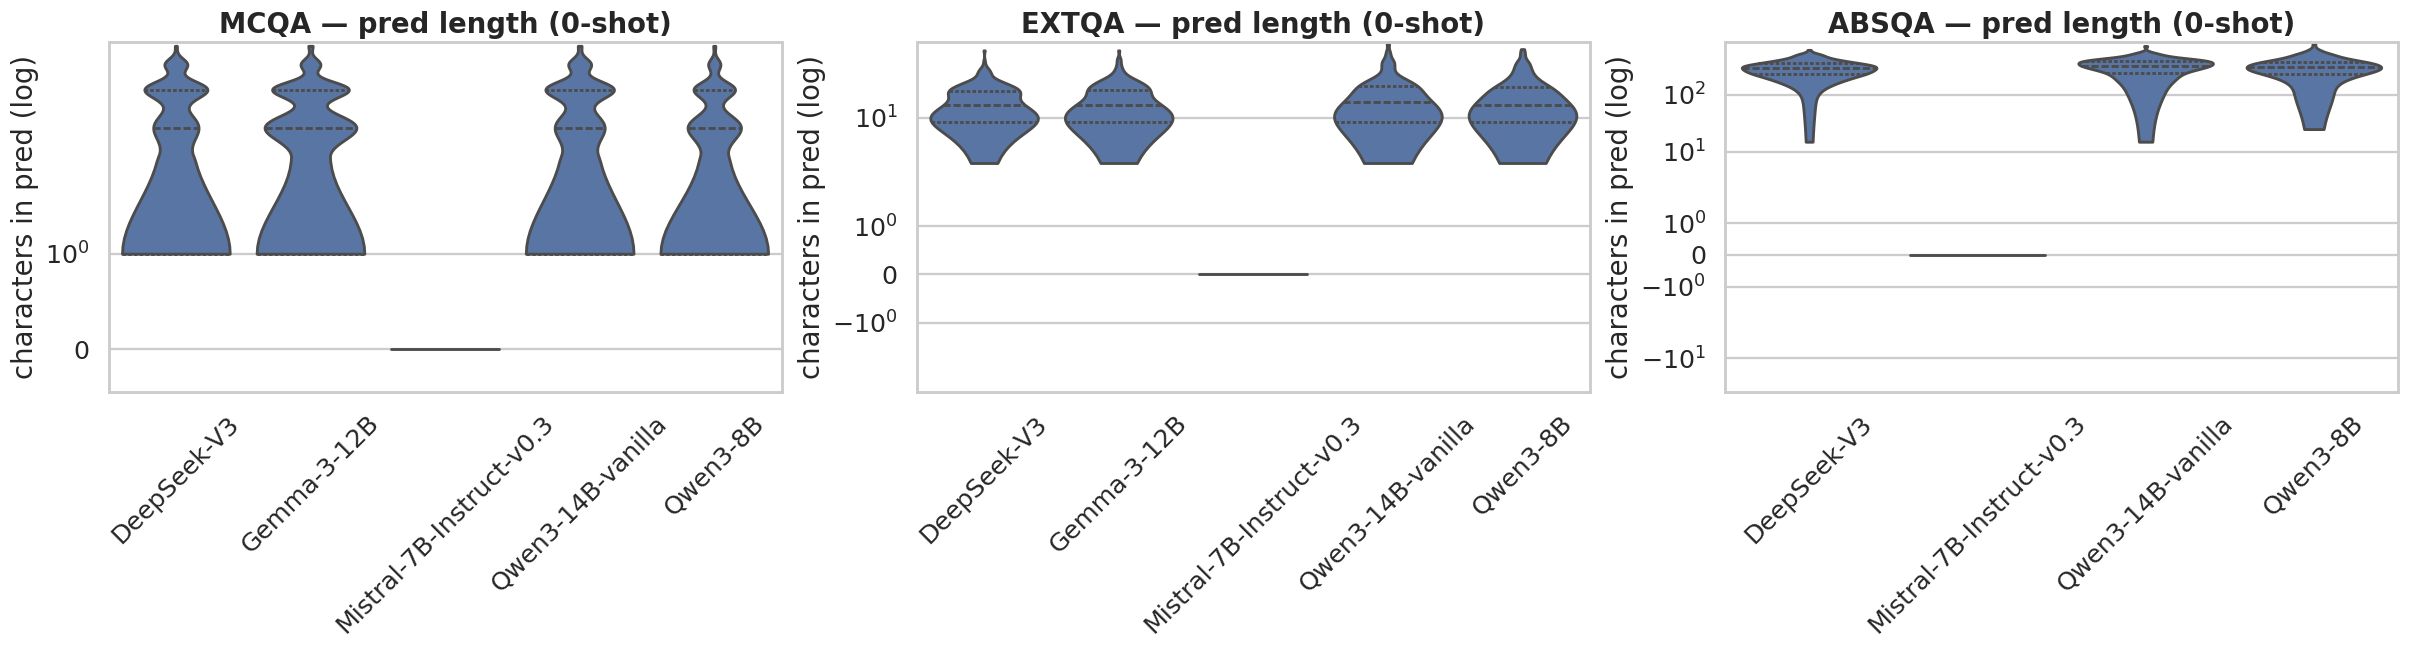

10:20:06 | I | ✓ /content/drive/MyDrive/00_PHD_THESIS/frmedqa-colab/RESULT/figures_deep/fig07_length_0shot.png


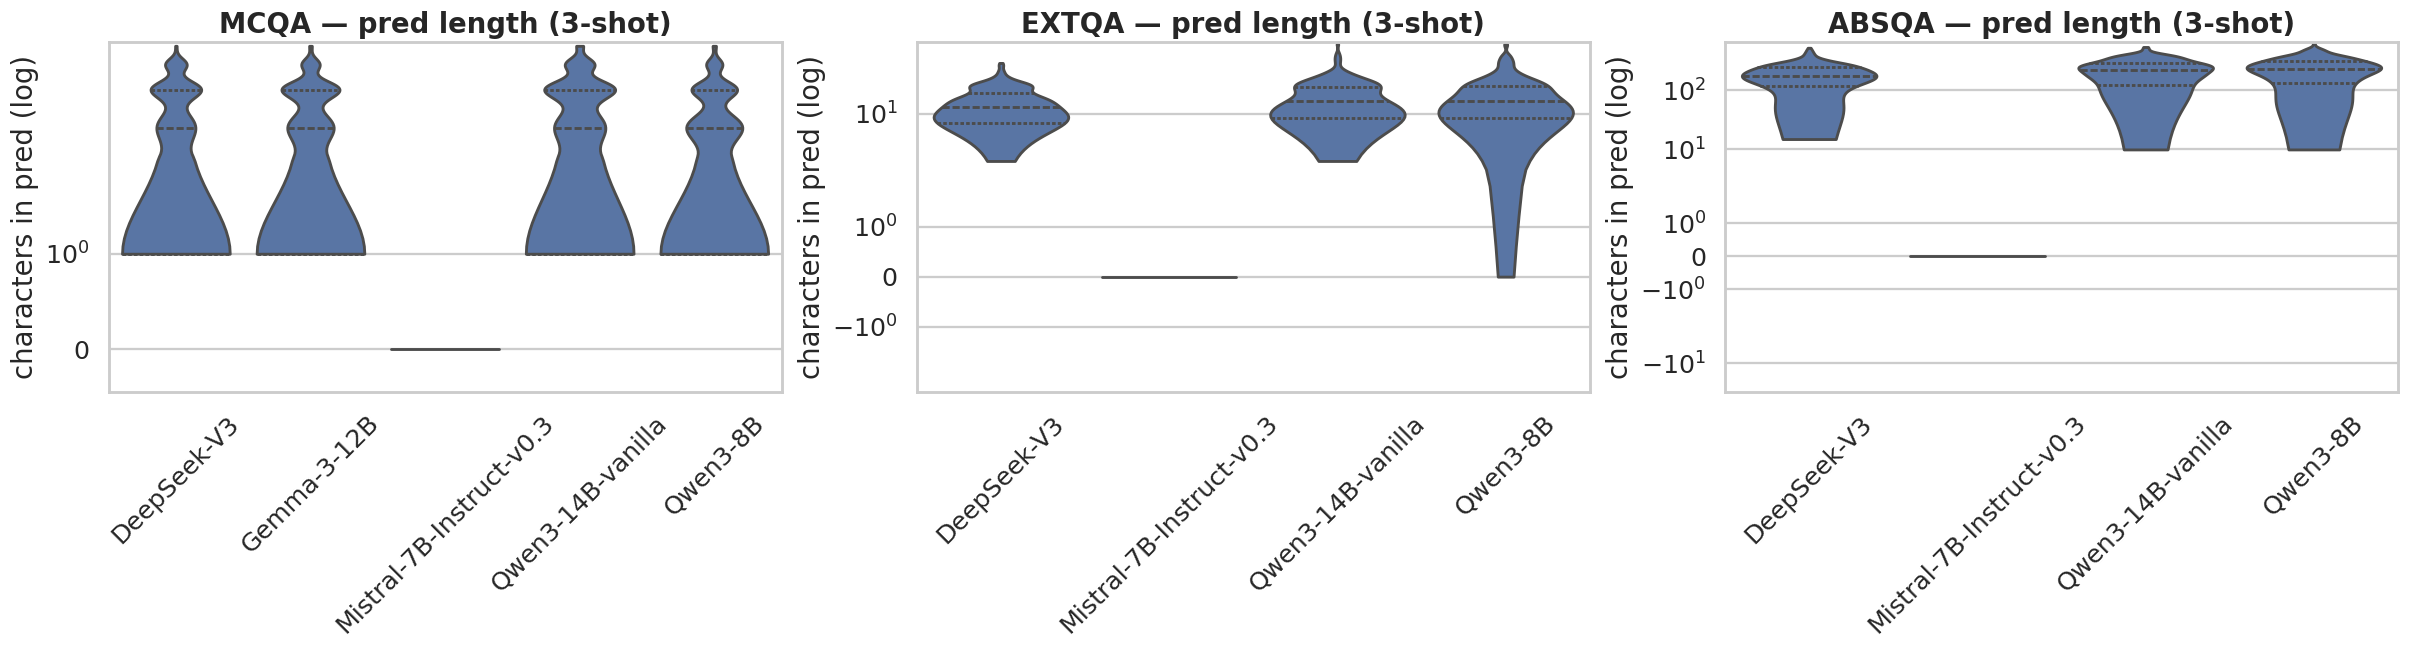

10:20:09 | I | ✓ /content/drive/MyDrive/00_PHD_THESIS/frmedqa-colab/RESULT/figures_deep/fig07_length_3shot.png


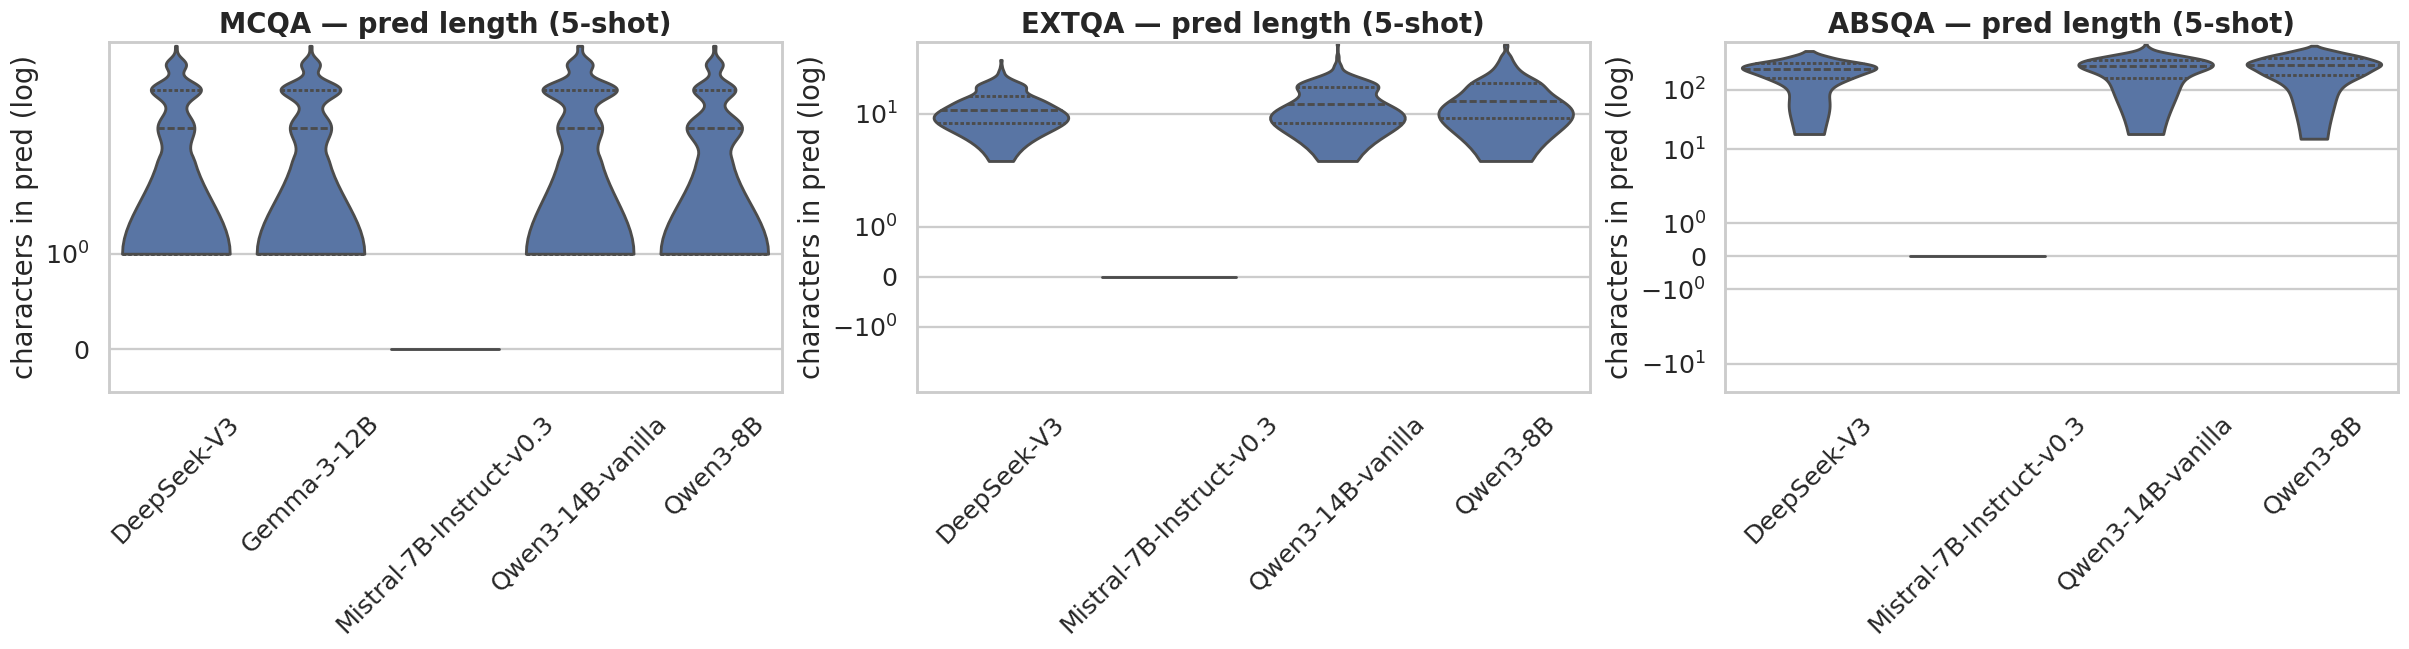

10:20:12 | I | ✓ /content/drive/MyDrive/00_PHD_THESIS/frmedqa-colab/RESULT/figures_deep/fig07_length_5shot.png


In [22]:
if "family" not in df_items.columns:
    df_items["family"] = df_items["model"].apply(tag)

for shot in SHOTS:
    fig, axes = plt.subplots(1, 3, figsize=(22, 6))
    drew = 0
    for ax, task in zip(axes, ALL_TASKS):
        sub = df_items[(df_items["task"]==task) & (df_items["n_shot"]==shot)]
        if sub.empty:
            ax.set_visible(False); continue
        order = sorted(sub[sub["family"]=="vanilla"]["model"].unique().tolist()) +                 [m for m in CANDIDATE_ORDER if m in sub["model"].unique().tolist()]
        if not order:
            ax.set_visible(False); continue
        sns.violinplot(data=sub, x="model", y="pred_len", order=order,
                       ax=ax, inner="quartile", cut=0, density_norm="width")
        ax.set_yscale("symlog")
        ax.set_title(f"{task.upper()} — pred length ({shot}-shot)")
        ax.set_xlabel(""); ax.set_ylabel("characters in pred (log)")
        ax.tick_params(axis="x", rotation=45)
        drew += 1
    if drew == 0: plt.close(fig); continue
    plt.tight_layout()
    out = os.path.join(FIG_DIR, f"fig07_length_{shot}shot.png")
    plt.savefig(out, bbox_inches="tight"); plt.show()
    logger.info(f"✓ {out}")

## 🩺 Stage 12 — Specialty / sub-domain breakdown (if metadata)

In [23]:
specialty_map = {}
if os.path.exists(TEST_PATH):
    rows = load_jsonl(TEST_PATH)
    for r in rows:
        spec = r.get("specialty") or r.get("category") or r.get("subset")
        if spec: specialty_map[r["id"]] = str(spec)
    logger.info(f"  loaded {len(specialty_map)} specialty tags from test.jsonl")
else:
    logger.warning(f"  {TEST_PATH} not found — skipping specialty plot")

if specialty_map:
    df_items["specialty"] = df_items["id"].map(specialty_map)
    has = df_items.dropna(subset=["specialty"])
    if len(has) > 50:
        sub = has[(has["task"]=="mcqa") & (has["n_shot"]==0)]
        if not sub.empty:
            pivot = sub.pivot_table(index="specialty", columns="model",
                                    values="score", aggfunc="mean")
            counts = sub.groupby("specialty").size()
            pivot = pivot.loc[counts[counts >= 10].index]
            if not pivot.empty:
                fig, ax = plt.subplots(figsize=(15, max(4, len(pivot)*0.4)))
                sns.heatmap(pivot.sort_index(), annot=True, fmt=".2f",
                            cmap="RdYlGn", vmin=0, vmax=1, ax=ax,
                            cbar_kws={"label":"MCQA accuracy"})
                ax.set_title("MCQA accuracy by medical specialty (0-shot)")
                plt.tight_layout()
                out = os.path.join(FIG_DIR, "fig08_specialty_breakdown.png")
                plt.savefig(out, bbox_inches="tight"); plt.show()
                logger.info(f"✓ {out}")
                pivot.to_csv(os.path.join(RESULTS_DIR, "specialty_breakdown.csv"))

10:20:14 | I |   loaded 207 specialty tags from test.jsonl


## ⚖️ Stage 13 — Gemma per-axis means with 95% CIs **per shot**For each shot, plot per-model means on each of the 4 axes + composite,with 95% confidence intervals on the means.

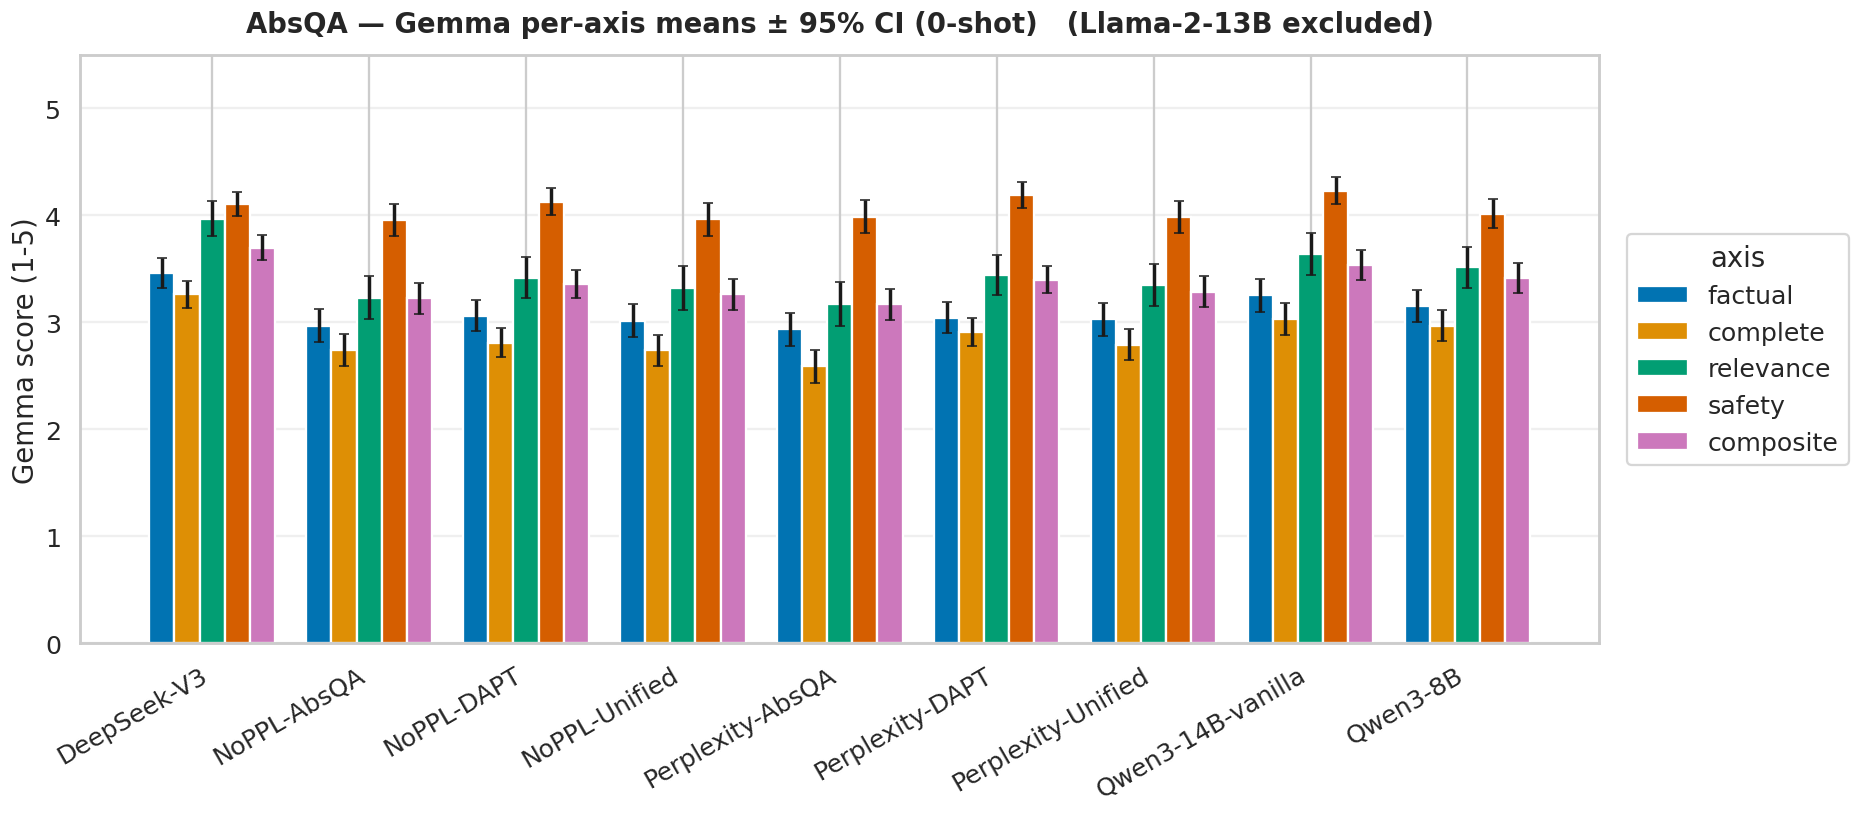

10:20:21 | I | ✓ /content/drive/MyDrive/00_PHD_THESIS/frmedqa-colab/RESULT/figures_deep/fig09_judge_axes_0shot.png


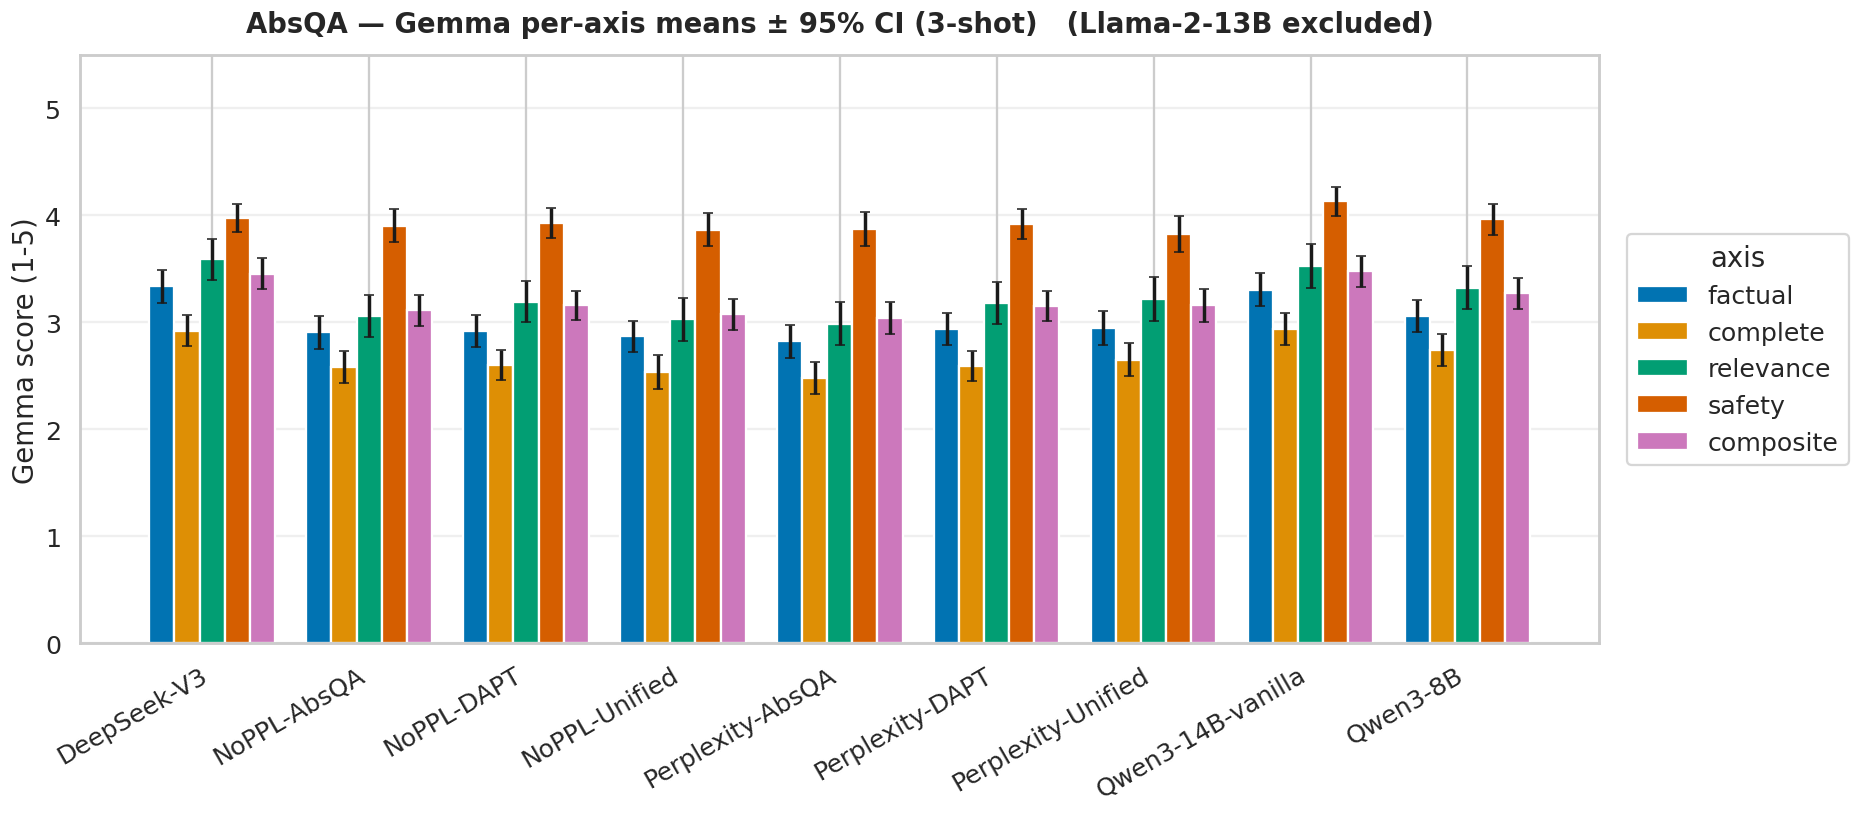

10:20:22 | I | ✓ /content/drive/MyDrive/00_PHD_THESIS/frmedqa-colab/RESULT/figures_deep/fig09_judge_axes_3shot.png


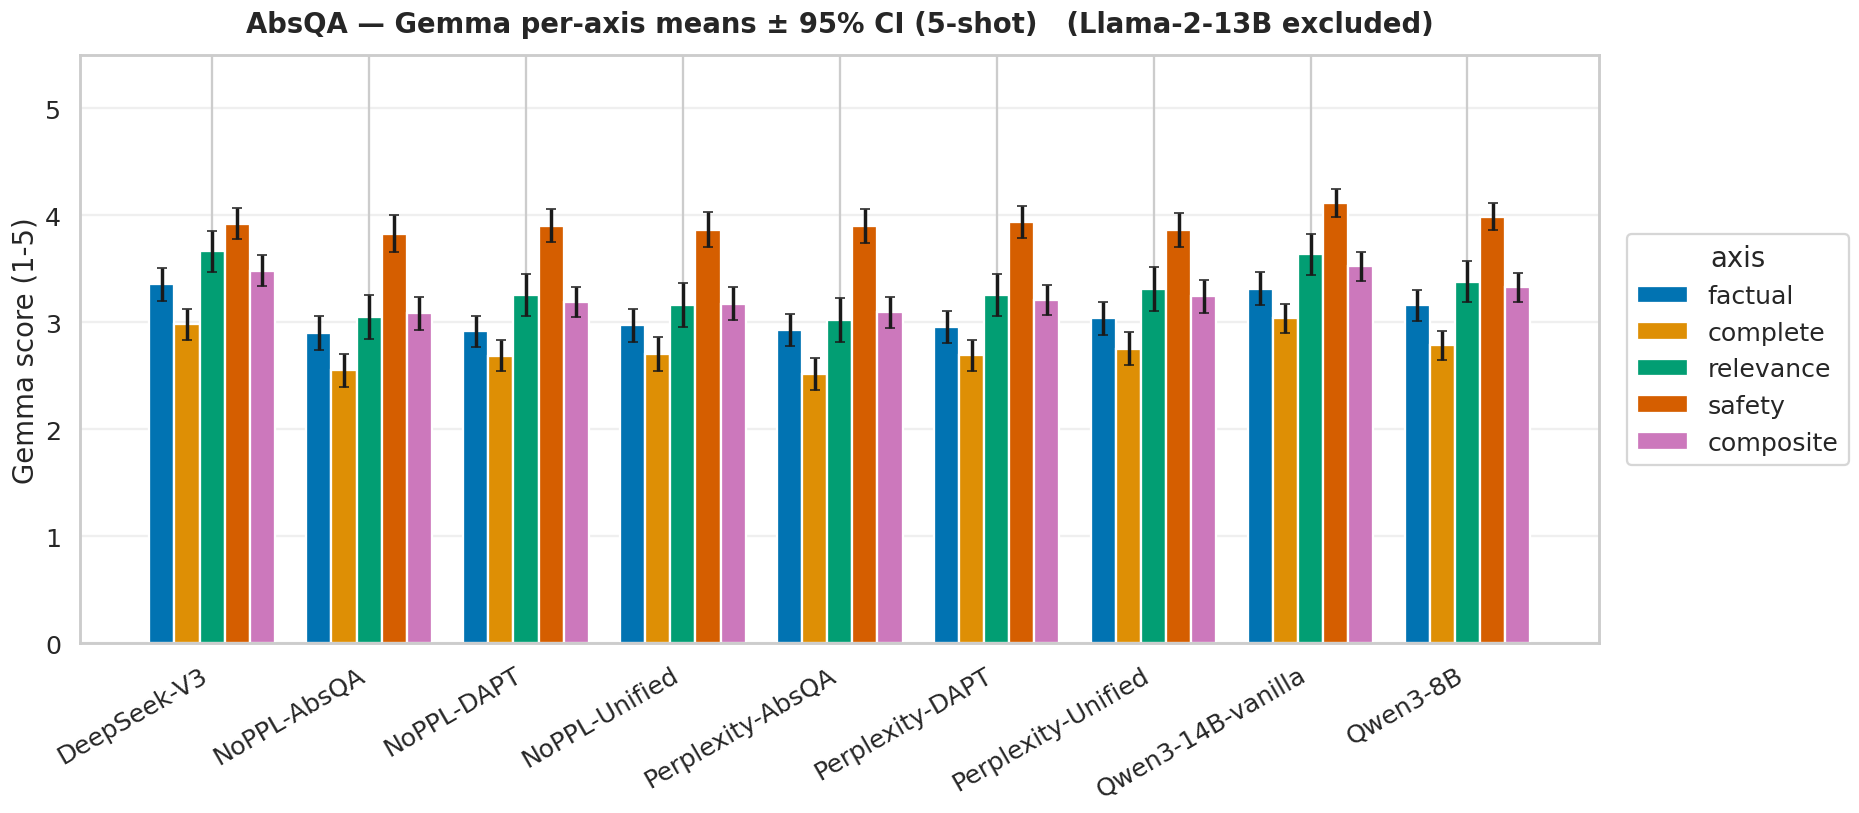

10:20:23 | I | ✓ /content/drive/MyDrive/00_PHD_THESIS/frmedqa-colab/RESULT/figures_deep/fig09_judge_axes_5shot.png


In [24]:
for shot in SHOTS:
    # Gather per-model per-axis arrays from gemma_per_row
    models_seen = sorted({m for (m, s, _a) in gemma_per_row.keys() if s == shot})
    if not models_seen:
        logger.warning(f"  no Gemma data for shot={shot}"); continue
    axes_to_plot = ["factual","complete","relevance","safety","composite"]

    fig, ax = plt.subplots(figsize=(17, 7.5))
    x = np.arange(len(models_seen))
    width = 0.16
    palette = sns.color_palette("colorblind", n_colors=len(axes_to_plot))
    for i, axis in enumerate(axes_to_plot):
        means, errs = [], []
        for m in models_seen:
            arr = list(gemma_per_row.get((m, shot, axis), {}).values())
            if not arr:
                means.append(np.nan); errs.append(0.0); continue
            mean = np.mean(arr)
            sem  = np.std(arr, ddof=1) / np.sqrt(len(arr)) if len(arr) > 1 else 0.0
            means.append(mean); errs.append(1.96 * sem)
        ax.bar(x + i*width - 2*width, means, width, yerr=errs, label=axis,
               capsize=3, color=palette[i])
    ax.set_xticks(x); ax.set_xticklabels(models_seen, rotation=30, ha="right")
    ax.set_ylabel("Gemma score (1-5)"); ax.set_ylim(0, 5.5)
    ax.set_title(f"AbsQA — Gemma per-axis means ± 95% CI ({shot}-shot)   "
                 f"(Qwen3-14B-vanilla vs Perplexity vs NoPPL)", pad=15)
    # Legend outside the plot to keep bars unobstructed
    ax.legend(title="axis", loc="center left", bbox_to_anchor=(1.01, 0.5),
              frameon=True)
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    out = os.path.join(FIG_DIR, f"fig09_judge_axes_{shot}shot.png")
    plt.savefig(out, bbox_inches="tight"); plt.show()
    logger.info(f"✓ {out}")

## 🎻 Stage 14 — Gemma per-axis distributions (violin/box)Means alone hide variance. Each violin shows the *spread* of per-row Gemma scores.

/tmp/ipykernel_1229/3872516630.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=sub, x="model", y="score", order=order_models, ax=ax,
/tmp/ipykernel_1229/3872516630.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=sub, x="model", y="score", order=order_models, ax=ax,
/tmp/ipykernel_1229/3872516630.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=sub, x="model", y="score", order=order_models, ax=ax,
/tmp/ipykernel_1229/3872516630.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecate

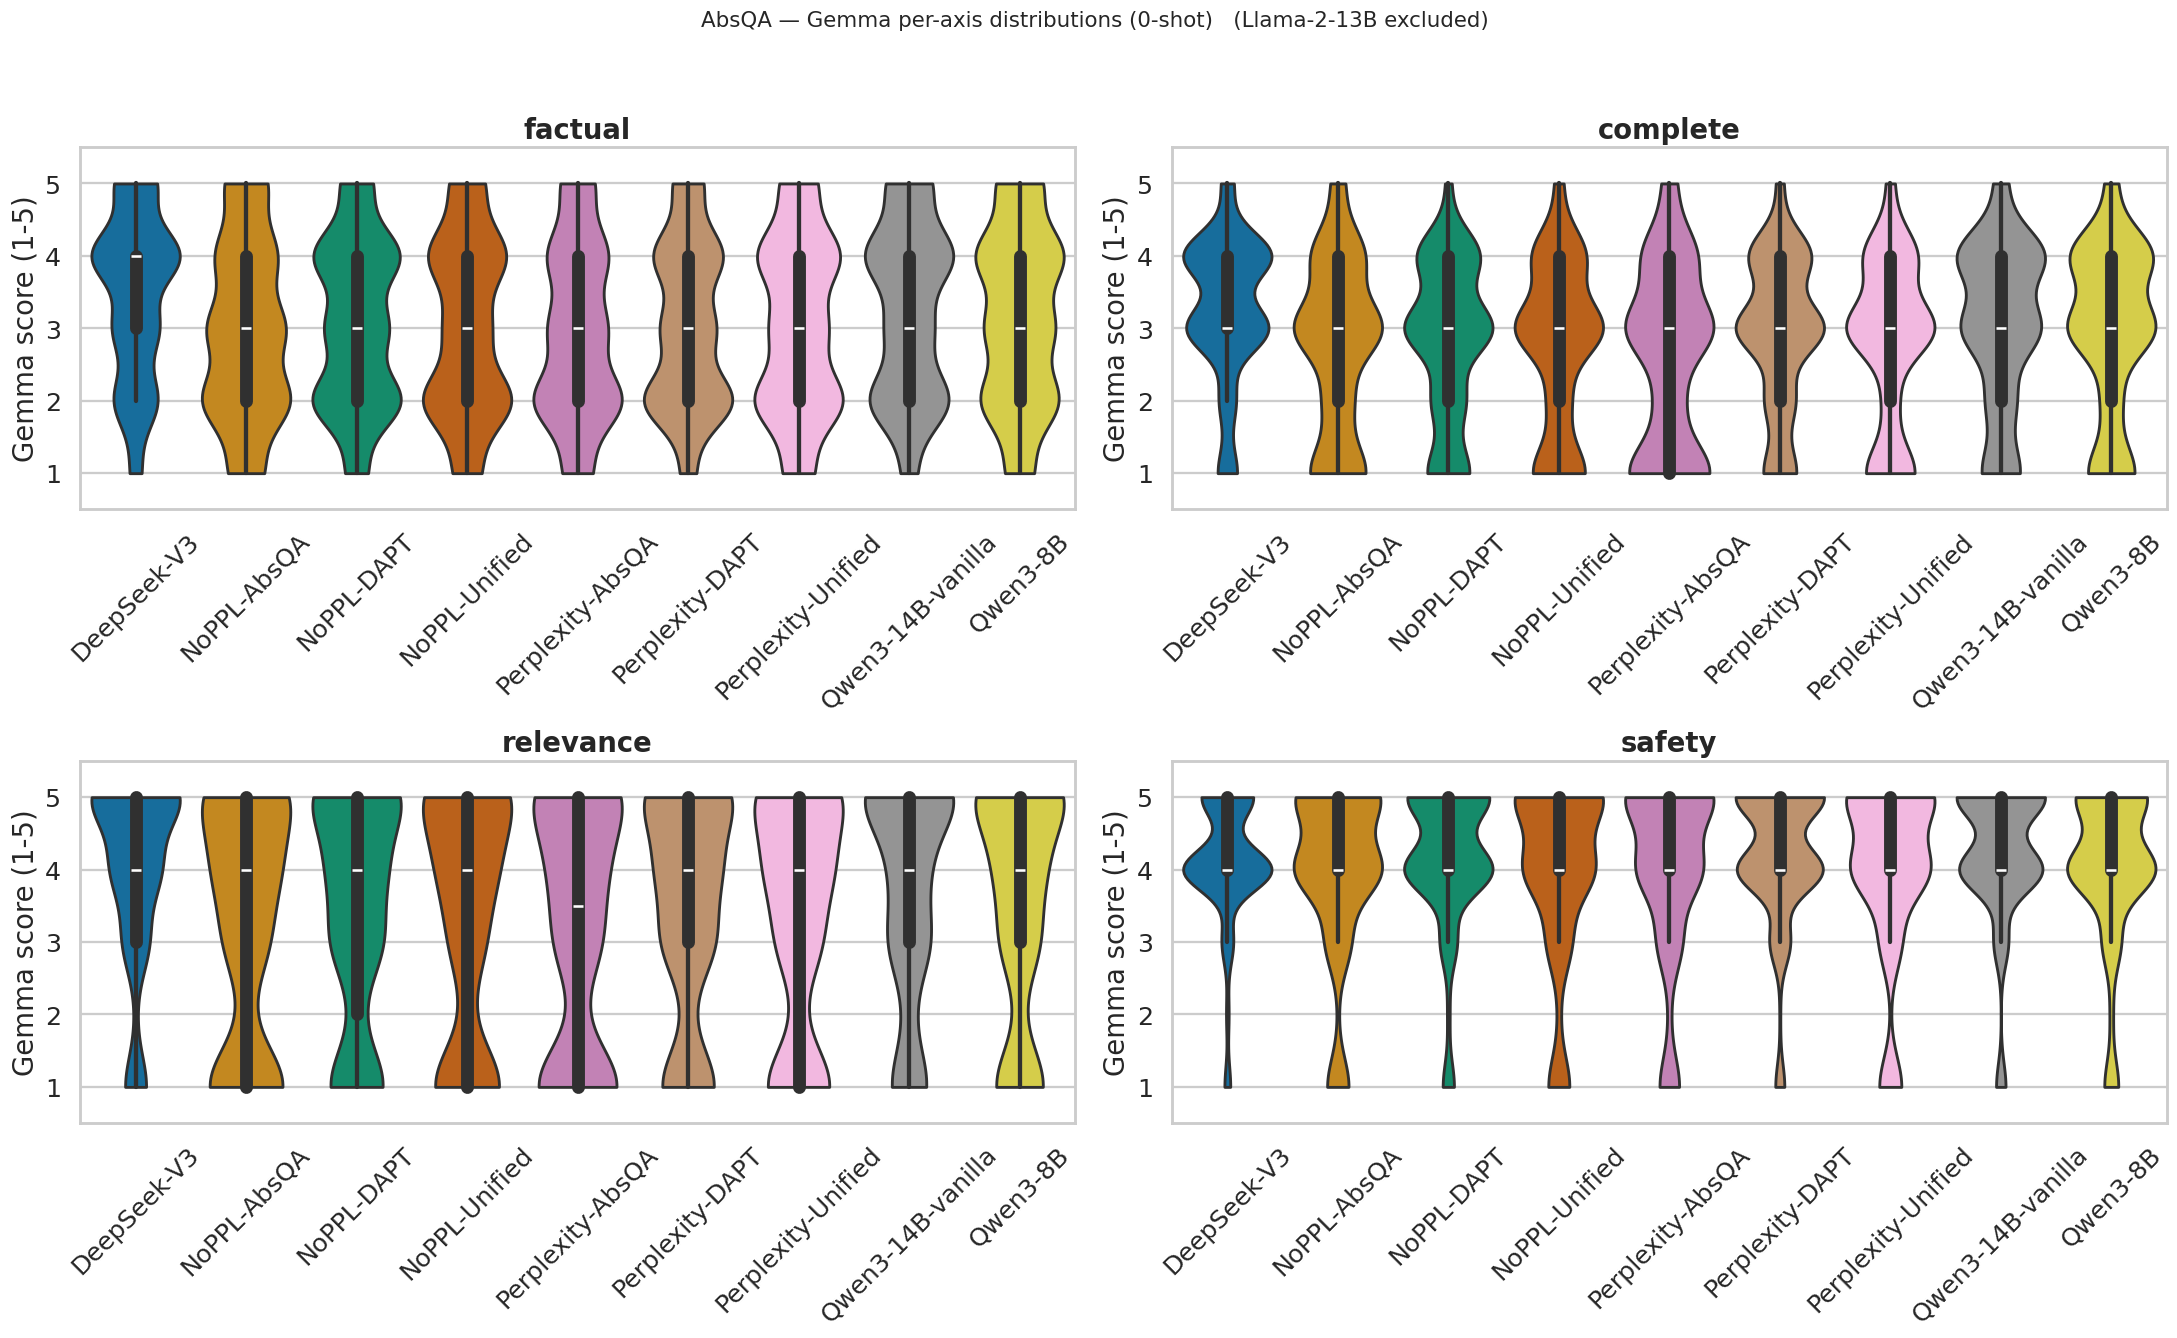

10:20:27 | I | ✓ /content/drive/MyDrive/00_PHD_THESIS/frmedqa-colab/RESULT/figures_deep/fig10_judge_distributions_0shot.png
/tmp/ipykernel_1229/3872516630.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=sub, x="model", y="score", order=order_models, ax=ax,
/tmp/ipykernel_1229/3872516630.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=sub, x="model", y="score", order=order_models, ax=ax,
/tmp/ipykernel_1229/3872516630.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=sub, x="model", y="score", order=order_

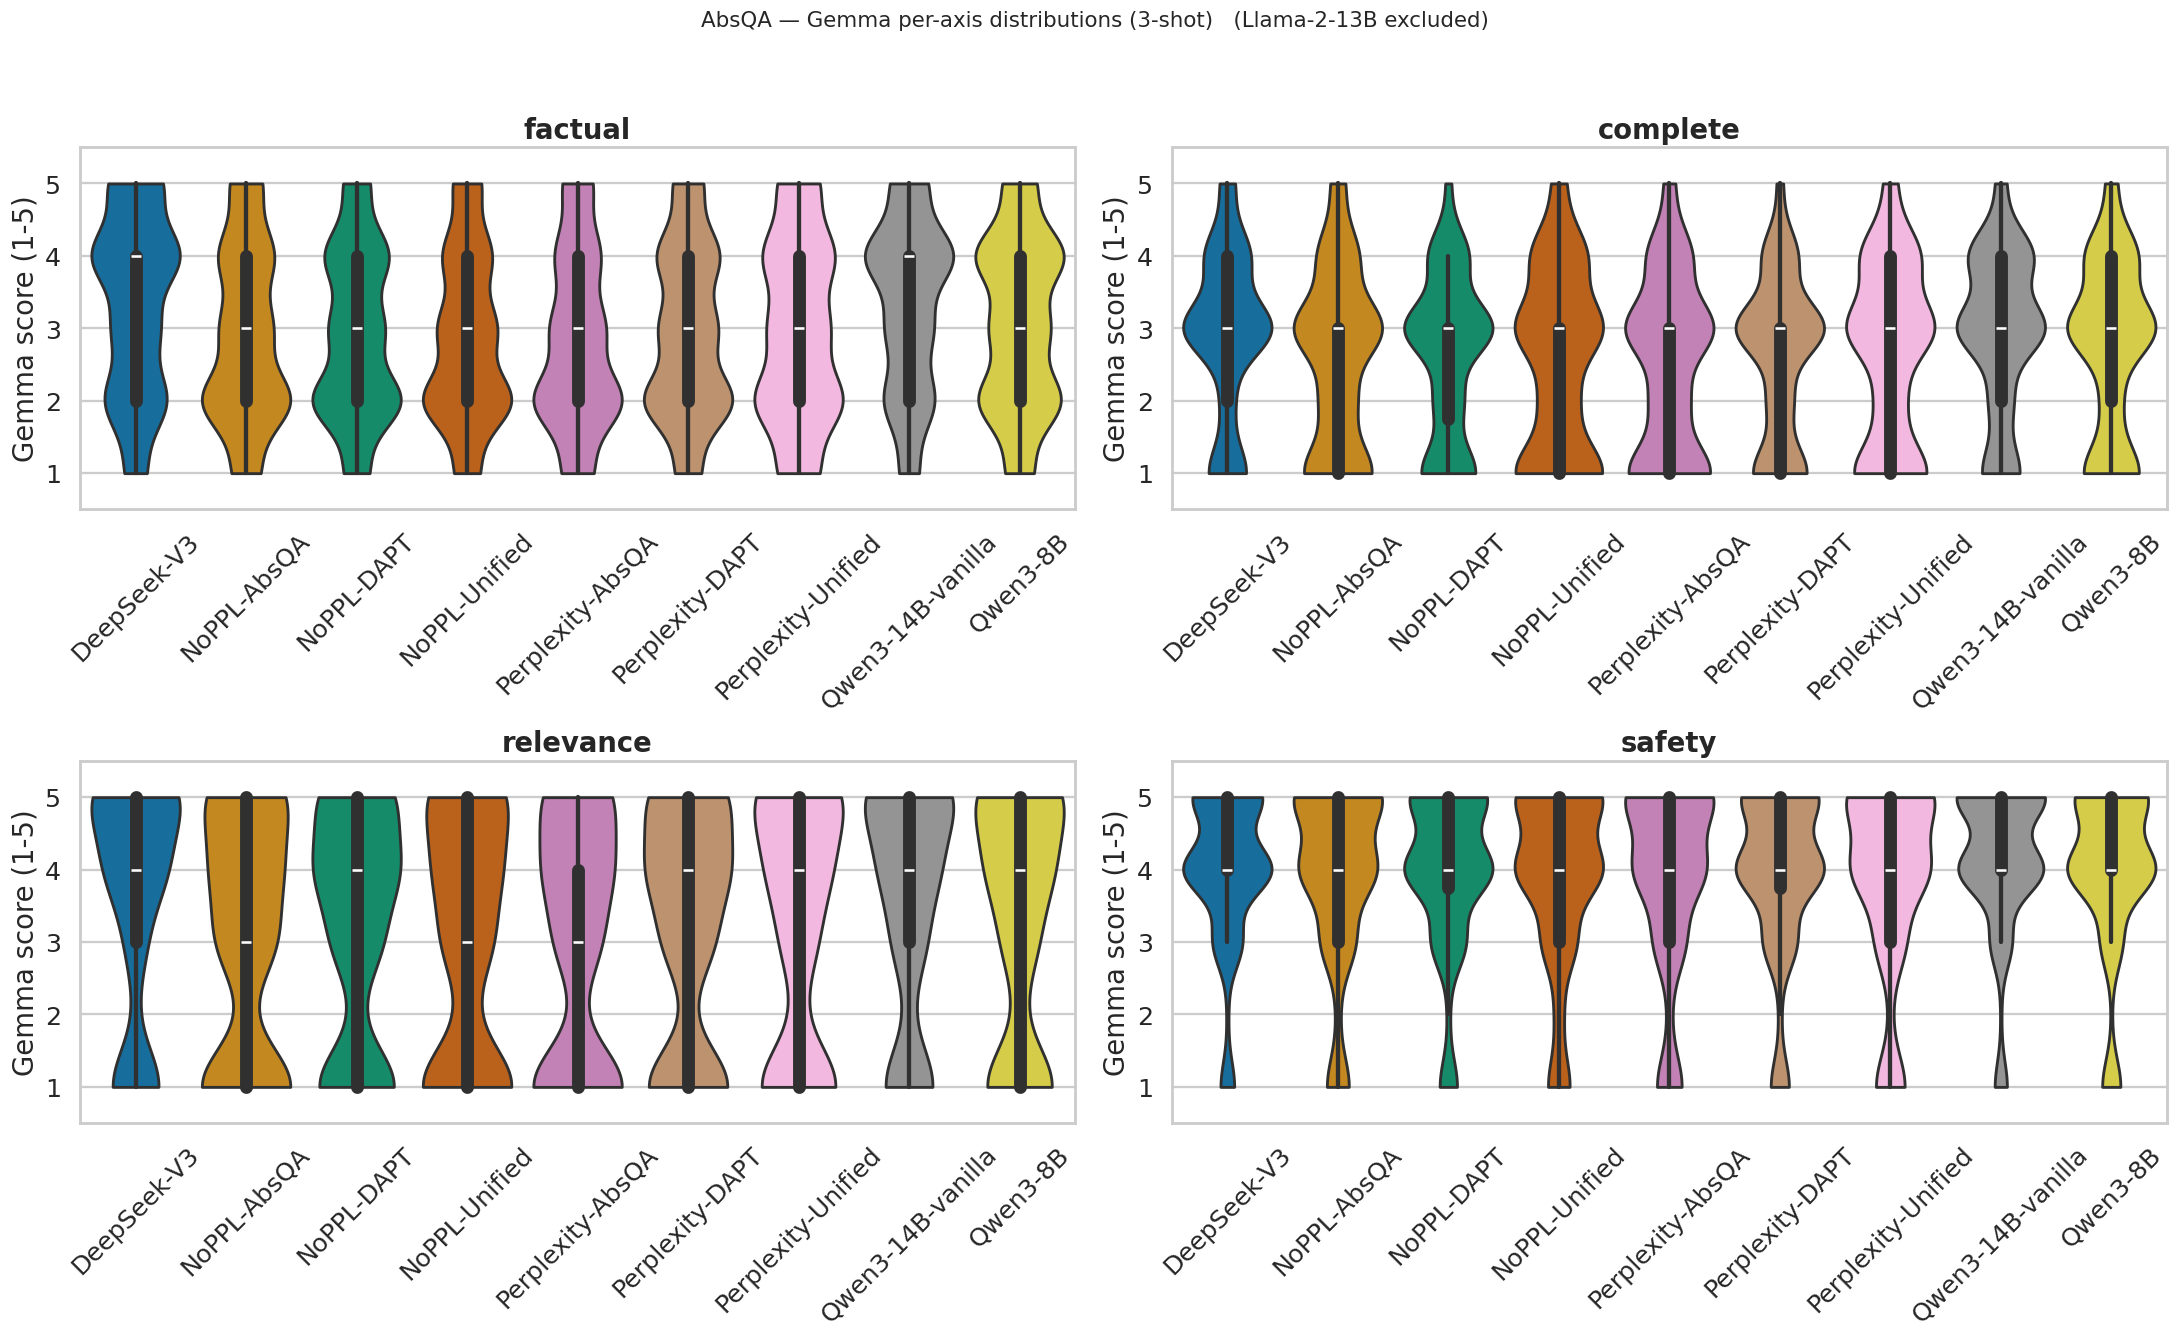

10:20:32 | I | ✓ /content/drive/MyDrive/00_PHD_THESIS/frmedqa-colab/RESULT/figures_deep/fig10_judge_distributions_3shot.png
/tmp/ipykernel_1229/3872516630.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=sub, x="model", y="score", order=order_models, ax=ax,
/tmp/ipykernel_1229/3872516630.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=sub, x="model", y="score", order=order_models, ax=ax,
/tmp/ipykernel_1229/3872516630.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=sub, x="model", y="score", order=order_

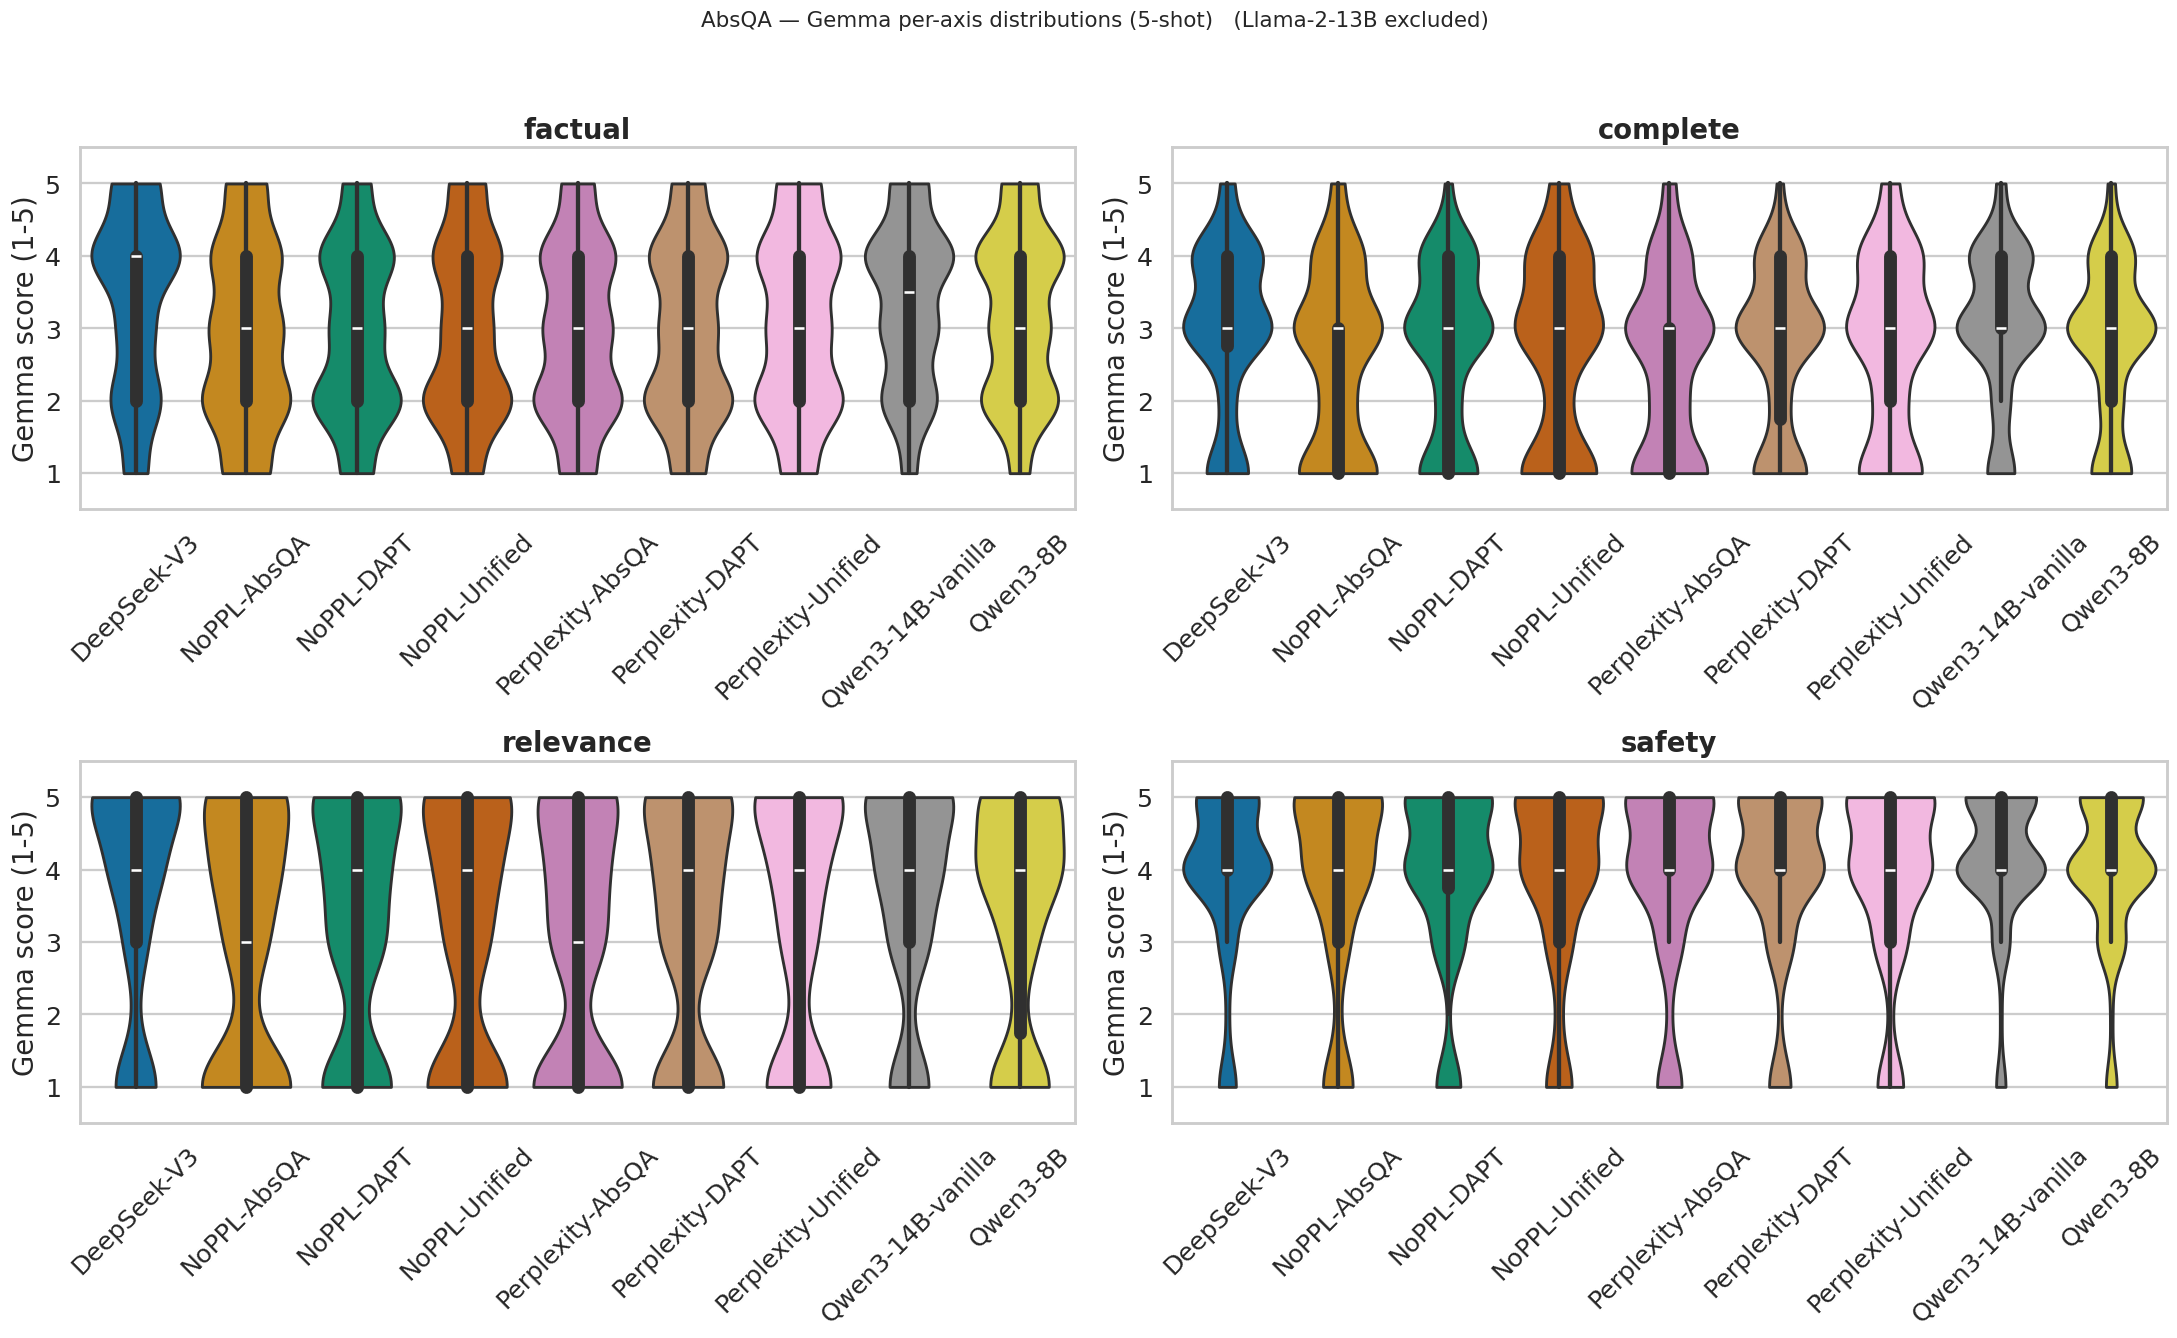

10:20:35 | I | ✓ /content/drive/MyDrive/00_PHD_THESIS/frmedqa-colab/RESULT/figures_deep/fig10_judge_distributions_5shot.png


In [25]:
for shot in SHOTS:
    # Build a long-format DataFrame
    rec = []
    for (m, s, axis), d in gemma_per_row.items():
        if s != shot: continue
        if axis == "composite": continue   # 4 axes only for distribution clarity
        for rid, v in d.items():
            rec.append({"model":m, "axis":axis, "score":v})
    if not rec: continue
    df_g = pd.DataFrame(rec)
    fig, axes = plt.subplots(2, 2, figsize=(20, 12))
    palette = sns.color_palette("colorblind", n_colors=df_g["model"].nunique())
    order_models = sorted(df_g["model"].unique())
    for ax, axis in zip(axes.flat, ["factual","complete","relevance","safety"]):
        sub = df_g[df_g["axis"]==axis]
        if sub.empty: ax.set_visible(False); continue
        sns.violinplot(data=sub, x="model", y="score", order=order_models, ax=ax,
                       inner="box", cut=0, density_norm="width", palette=palette)
        ax.set_title(f"{axis}")
        ax.set_ylim(0.5, 5.5); ax.set_xlabel(""); ax.set_ylabel("Gemma score (1-5)")
        ax.tick_params(axis="x", rotation=45)
    plt.suptitle(f"AbsQA — Gemma per-axis distributions ({shot}-shot)   "
                 f"(Qwen3-14B-vanilla vs Perplexity vs NoPPL)", y=1.01, fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    out = os.path.join(FIG_DIR, f"fig10_judge_distributions_{shot}shot.png")
    plt.savefig(out, bbox_inches="tight"); plt.show()
    logger.info(f"✓ {out}")

## 🔗 Stage 15 — Inter-axis correlation per modelFor each model: how correlated are its per-row factual / complete / relevance / safety scores?A model with all axes near-perfectly correlated isn't really being judged on 4 things — it's being judged on 1.

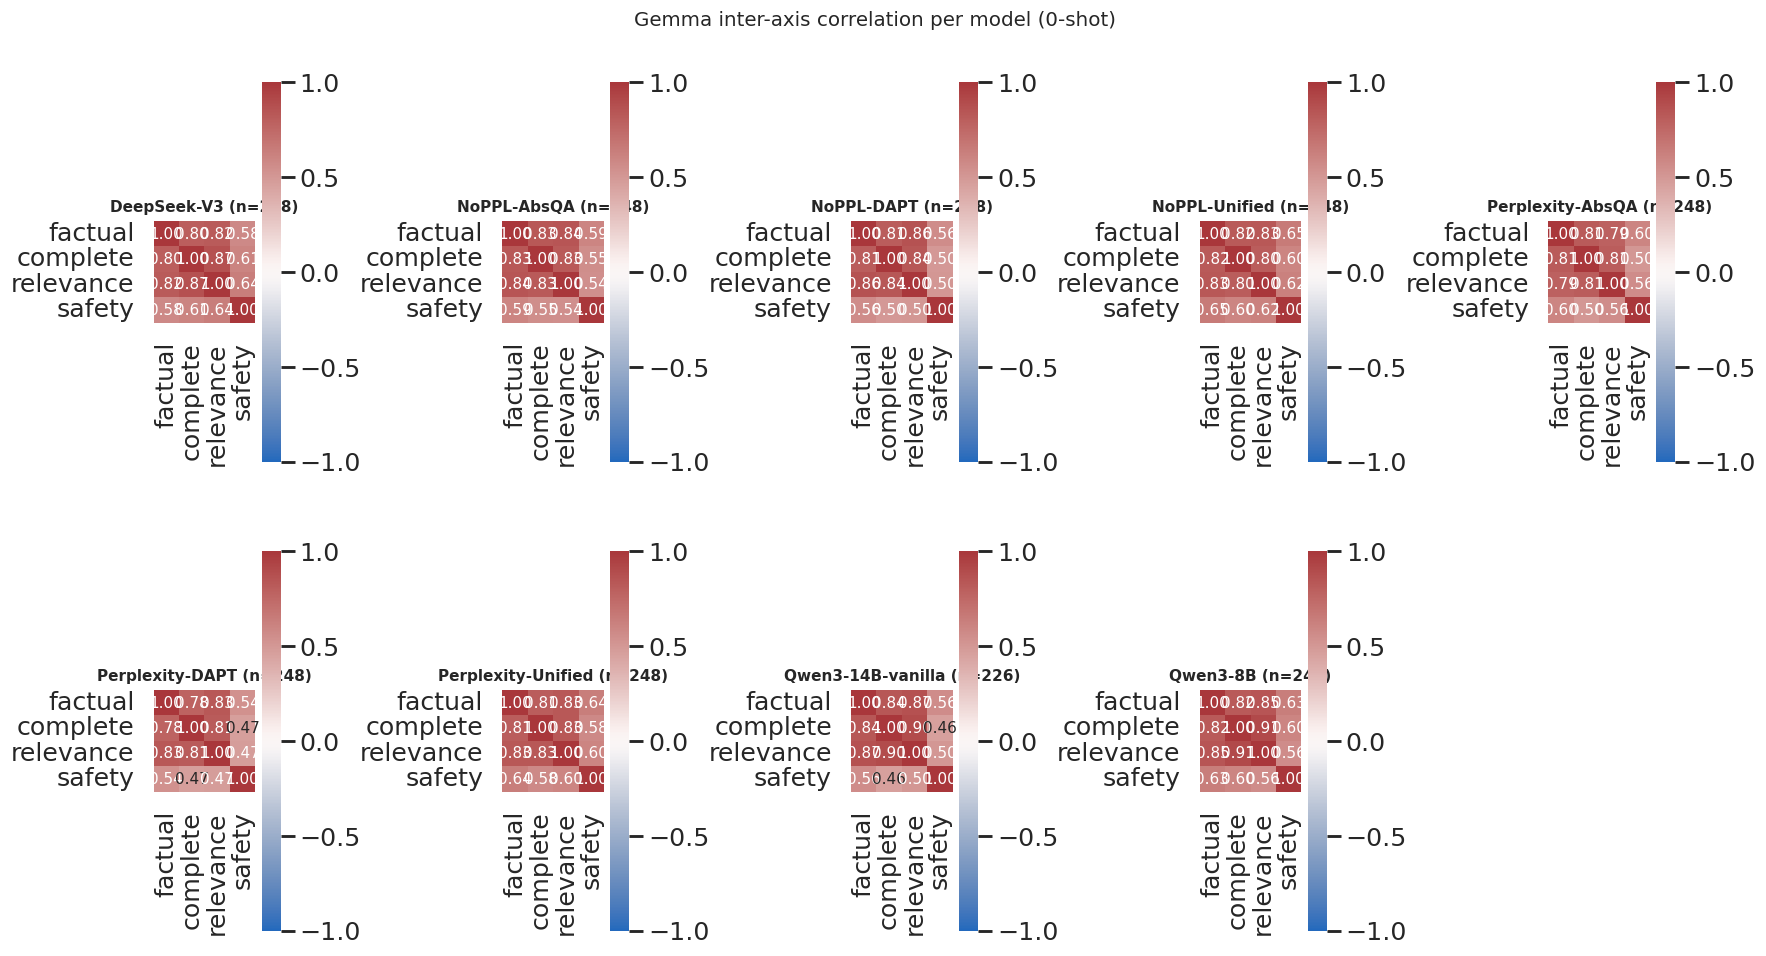

10:20:41 | I | ✓ /content/drive/MyDrive/00_PHD_THESIS/frmedqa-colab/RESULT/figures_deep/fig11_gemma_axis_correlation.png


In [26]:
# For each model, build a (n_rows × 4) matrix → corr matrix
models_seen = sorted({m for (m, _s, _a) in gemma_per_row.keys()})
shot = 0   # use 0-shot for cleanest signal
fig, axes = plt.subplots(2, max(1, (len(models_seen)+1)//2), figsize=(16, 9))
flat = axes.flat if hasattr(axes, "flat") else [axes]
drew = 0
for ax_h, model in zip(flat, models_seen):
    # Build aligned arrays per axis
    common = None
    series = {}
    for axis in ["factual","complete","relevance","safety"]:
        d = gemma_per_row.get((model, shot, axis), {})
        if not d:
            common = set(); break
        if common is None: common = set(d)
        else: common &= set(d)
        series[axis] = d
    if not common:
        ax_h.set_visible(False); continue
    common_sorted = sorted(common)
    arr = np.array([[series[a][rid] for a in ["factual","complete","relevance","safety"]]
                    for rid in common_sorted])
    if arr.shape[0] < 5:
        ax_h.set_visible(False); continue
    corr = pd.DataFrame(arr, columns=["factual","complete","relevance","safety"]).corr()
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0, vmin=-1, vmax=1,
                ax=ax_h, cbar=True, square=True)
    ax_h.set_title(f"{model} (n={len(common_sorted)})", fontsize=10)
    drew += 1
# Hide unused axes
for k in range(drew, len(flat)):
    flat[k].set_visible(False)
plt.suptitle(f"Gemma inter-axis correlation per model (0-shot)", y=1.01, fontsize=13)
plt.tight_layout()
out = os.path.join(FIG_DIR, "fig11_gemma_axis_correlation.png")
plt.savefig(out, bbox_inches="tight"); plt.show()
logger.info(f"✓ {out}")

## 🔬 Stage 16 — Per-axis significance heatmap (each Perplexity-* / NoPPL-* vs Qwen3-14B-vanilla, per Gemma axis, 0-shot)

In [27]:
# Build, per Gemma axis, an effect-size heatmap (row=Qwen3-14B-vanilla, cols=candidates)
shot = 0
panels = []
for axis in ["factual","complete","relevance","safety","composite"]:
    rows_h = []
    has_any = False
    for m_van in [VANILLA_REF]:
        row = []
        for m_en in CANDIDATE_ORDER:
            if "absqa" not in _model_tasks(m_en): row.append(np.nan); continue
            a, b = get_paired_gemma(m_van, m_en, axis, shot)
            if a is None: row.append(np.nan); continue
            row.append(cohens_d_paired(a, b)); has_any = True
        rows_h.append(row)
    if has_any:
        panels.append((axis, pd.DataFrame(rows_h, index=[VANILLA_REF], columns=CANDIDATE_ORDER)))

if panels:
    fig, axes = plt.subplots(1, len(panels), figsize=(6*len(panels), 3.5))
    if len(panels) == 1: axes = [axes]
    for ax, (axis, H) in zip(axes, panels):
        sns.heatmap(H, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
                    vmin=-1.5, vmax=1.5, ax=ax,
                    cbar_kws={"label":"Cohen's d"},
                    annot_kws={"fontsize":9})
        ax.set_title(f"Gemma {axis}")
        ax.set_xlabel("Perplexity-* | NoPPL-*"); ax.set_ylabel("")
    plt.suptitle("AbsQA Gemma per-axis effect sizes — 0-shot   "
                 "(positive = candidate beats Qwen3-14B-vanilla)",
                 y=1.02, fontsize=13)
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    out = os.path.join(FIG_DIR, "fig12_gemma_axis_effect_size.png")
    plt.savefig(out, bbox_inches="tight"); plt.show()
    logger.info(f"✓ {out}")

## 📉 Stage 17 — Failure taxonomy stacked bars **per shot**

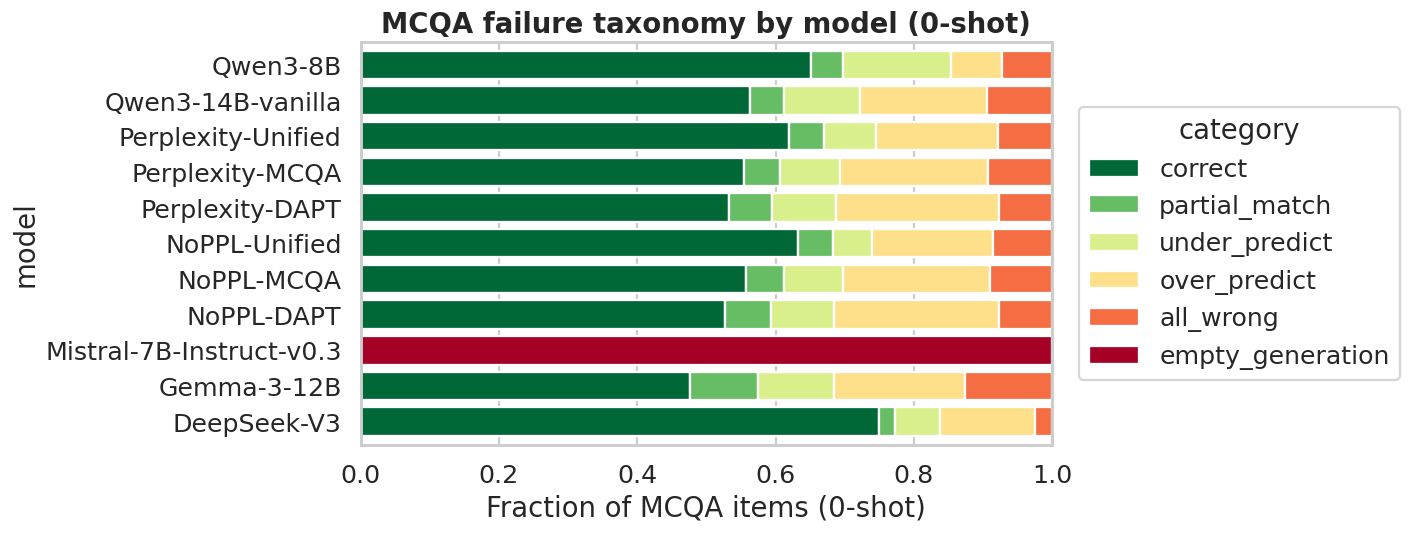

10:20:42 | I | ✓ /content/drive/MyDrive/00_PHD_THESIS/frmedqa-colab/RESULT/figures_deep/fig13_failure_taxonomy_0shot.png


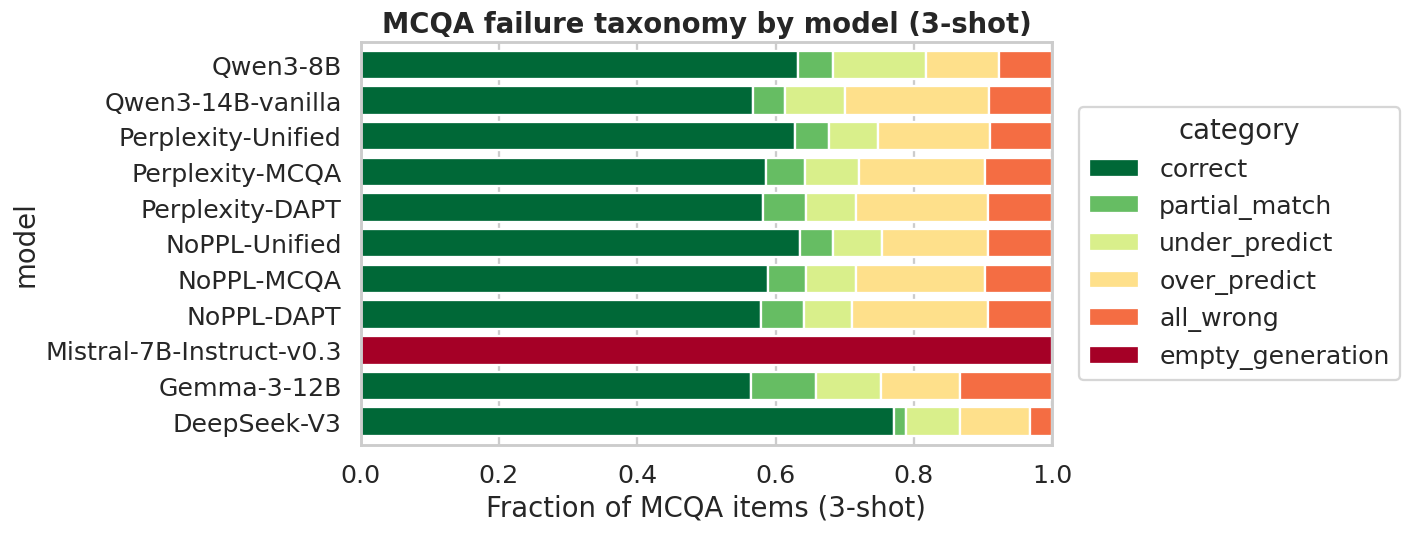

10:20:44 | I | ✓ /content/drive/MyDrive/00_PHD_THESIS/frmedqa-colab/RESULT/figures_deep/fig13_failure_taxonomy_3shot.png


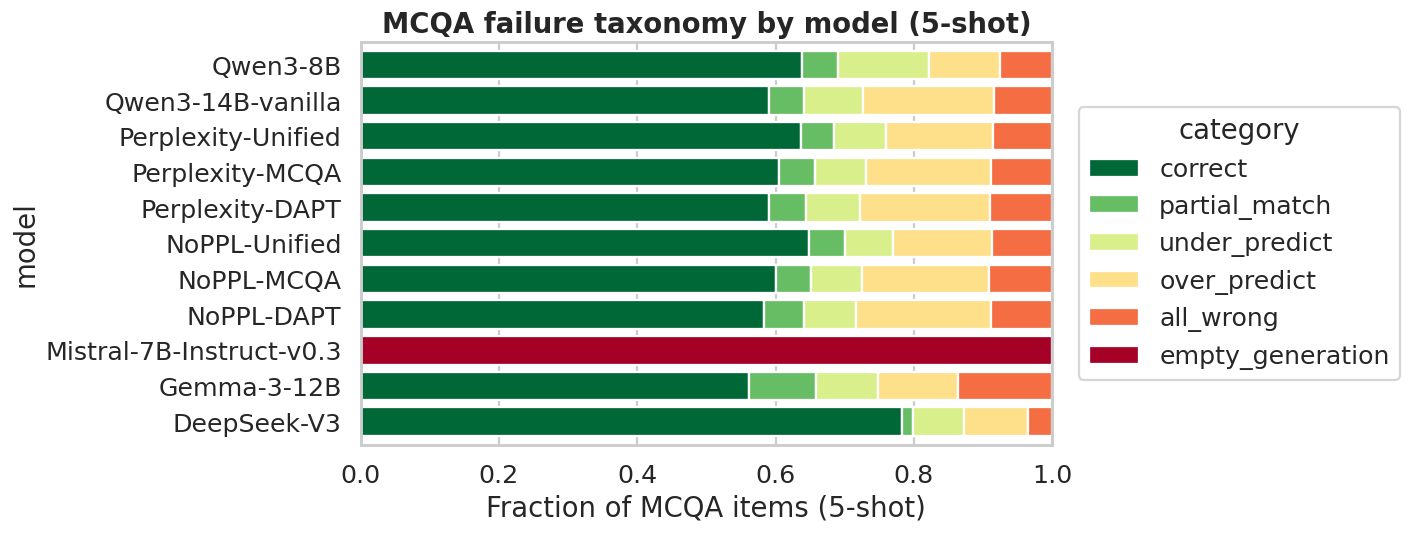

10:20:45 | I | ✓ /content/drive/MyDrive/00_PHD_THESIS/frmedqa-colab/RESULT/figures_deep/fig13_failure_taxonomy_5shot.png


In [28]:
def classify_mcqa(r):
    pred = (r.get("pred_judged") or r.get("pred") or "").strip()
    gold = (r.get("gold") or "").strip()
    raw  = (r.get("raw") or "").strip()
    if not raw: return "empty_generation"
    if not pred: return "format_failure"
    p, g = set(pred.split(",")), set(gold.split(","))
    if p == g: return "correct"
    if not p & g: return "all_wrong"
    if p < g: return "under_predict"
    if p > g: return "over_predict"
    return "partial_match"


for shot in SHOTS:
    rec = []
    for f in os.listdir(EVAL_CACHE_DIR):
        if not f.endswith(".json") or "__mcqa__" not in f: continue
        d = json.load(open(os.path.join(EVAL_CACHE_DIR, f), encoding="utf-8"))
        if d.get("n_shot") != shot: continue
        for r in d.get("rows", []):
            rec.append({"model":d["model"], "category":classify_mcqa(r)})
    if not rec: continue
    dfx = pd.DataFrame(rec)
    pivot = dfx.groupby(["model","category"]).size().unstack(fill_value=0)
    pivot = pivot.div(pivot.sum(axis=1), axis=0)
    cats_order = ["correct","partial_match","under_predict","over_predict",
                  "all_wrong","format_failure","empty_generation"]
    pivot = pivot[[c for c in cats_order if c in pivot.columns]]
    if pivot.empty: continue
    fig, ax = plt.subplots(figsize=(13, max(4, len(pivot)*0.45)))
    pivot.plot(kind="barh", stacked=True, ax=ax, width=0.8, colormap="RdYlGn_r")
    ax.set_xlabel(f"Fraction of MCQA items ({shot}-shot)")
    ax.set_xlim(0, 1)
    ax.set_title(f"MCQA failure taxonomy by model ({shot}-shot)")
    ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), title="category")
    plt.tight_layout()
    out = os.path.join(FIG_DIR, f"fig13_failure_taxonomy_{shot}shot.png")
    plt.savefig(out, bbox_inches="tight"); plt.show()
    logger.info(f"✓ {out}")
    pivot.to_csv(os.path.join(RESULTS_DIR, f"failure_taxonomy_{shot}shot.csv"))

## 📐 Stage 18 — Wilcoxon 0-vs-5 + Critical Difference per shot

In [29]:
from scipy import stats

# Long-format: one row per (model, task, n_shot, primary_score)
prim = []
for r in df_metrics.to_dict("records"):
    if r["metric"] == PRIMARY_METRIC.get(r["task"]):
        prim.append({"model":r["model"], "task":r["task"],
                     "n_shot":r["n_shot"], "score":r["value"]})
df_prim = pd.DataFrame(prim)

# Wilcoxon 0 vs 5 per model
wil = []
for model, g in df_prim.groupby("model"):
    s0 = g[g["n_shot"]==0].set_index("task")["score"]
    s5 = g[g["n_shot"]==5].set_index("task")["score"]
    common = s0.index.intersection(s5.index)
    if len(common) < 2: continue
    try: W, p = stats.wilcoxon(s0.loc[common], s5.loc[common])
    except Exception: W, p = None, None
    wil.append({"model":model,
                "mean_0shot":float(s0.loc[common].mean()),
                "mean_5shot":float(s5.loc[common].mean()),
                "delta":float(s5.loc[common].mean()-s0.loc[common].mean()),
                "wilcoxon_W":W, "wilcoxon_p":p})
df_wil = pd.DataFrame(wil).sort_values("delta", ascending=False)
print(df_wil.to_string(index=False))
df_wil.to_csv(os.path.join(RESULTS_DIR, "wilcoxon_0vs5.csv"), index=False)


def cd_diagram(df_prim, n_shot, fname):
    sub = df_prim[df_prim["n_shot"]==n_shot]
    if sub.empty: return
    pivot = sub.pivot(index="task", columns="model", values="score").dropna()
    if pivot.empty or pivot.shape[1] < 2 or pivot.shape[0] < 2: return
    ranks = pivot.rank(axis=1, ascending=False).mean(axis=0).sort_values()
    k = len(ranks); N = len(pivot)
    Q = {2:1.960,3:2.343,4:2.569,5:2.728,6:2.850,7:2.949,8:3.031,9:3.102,
         10:3.164,11:3.219,12:3.268,13:3.313,14:3.354,15:3.391}
    q = Q.get(min(k,15), 3.391)
    cd = q * np.sqrt(k*(k+1)/(6.0*N))
    fig, ax = plt.subplots(figsize=(13, max(3, k*0.4)))
    y = np.arange(len(ranks))

    markers = ["o", "s", "D", "^", "v", "p", "*", "h", "H", "d"]
    hatches = ["///", "\\\\\\", "|||", "---", "+++", "xxx", "...", "***", "OOO"]

    for idx, (yi, m) in enumerate(zip(y, ranks.index)):
        marker = markers[idx % len(markers)]
        hatch = hatches[idx % len(hatches)]
        ax.scatter([ranks[m]], [yi], s=120, facecolors="white", edgecolors="black",
                   marker=marker, hatch=hatch, zorder=3)
        ax.text(ranks[m], yi, f"  {m} ({ranks[m]:.2f})", va="center", fontsize=10, color="black")

    x_min = ranks.min()
    ax.plot([x_min, x_min+cd], [-1, -1], color="black", linestyle="--", linewidth=3)
    ax.text(x_min + cd/2, -1.4, f"CD = {cd:.2f}", ha="center", color="black")
    ax.set_yticks([]); ax.set_xlabel("avg rank (lower = better)", color="black")
    ax.set_title(f"Critical Difference — {n_shot}-shot", color="black")
    plt.tight_layout()
    out = os.path.join(FIG_DIR, fname)
    plt.savefig(out, bbox_inches="tight"); plt.show()
    logger.info(f"✓ {out}")

for s in SHOTS:
    cd_diagram(df_prim, s, f"fig14_cd_{s}shot.png")

/usr/local/lib/python3.13/dist-packages/scipy/stats/_wilcoxon.py:178: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se


                   model  mean_0shot  mean_5shot     delta  wilcoxon_W  wilcoxon_p
       Qwen3-14B-vanilla    1.534636    1.547510  0.012874         1.0        0.50
Mistral-7B-Instruct-v0.3    0.002415    0.002415  0.000000         0.0        1.00
           NoPPL-Unified    1.462068    1.450041 -0.012027         3.0        1.00
      Perplexity-Unified    1.480703    1.465855 -0.014848         1.0        0.50
              NoPPL-DAPT    1.458196    1.433606 -0.024590         3.0        1.00
         Perplexity-DAPT    1.471529    1.443744 -0.027784         3.0        1.00
                Qwen3-8B    1.539800    1.502153 -0.037647         0.0        0.25
             DeepSeek-V3    1.656698    1.609297 -0.047401         3.0        1.00


## 📋 Stage 19 — Final results table (paper-ready, no BERTScore)

In [30]:
# Wide table: rows=model, columns=(task, n_shot)
prim2 = []
for r in df_metrics.to_dict("records"):
    if r["metric"] == PRIMARY_METRIC.get(r["task"]) and r["value"] is not None:
        prim2.append({"model":r["model"], "task":r["task"],
                      "n_shot":r["n_shot"], "score":r["value"]})
df_prim2 = pd.DataFrame(prim2)
if not df_prim2.empty:
    wide = df_prim2.pivot_table(index="model", columns=["task","n_shot"],
                                values="score", aggfunc="mean").round(4)
    print(wide.to_string())
    wide.to_csv(os.path.join(RESULTS_DIR, "final_results_table.csv"))
    logger.info(f"✓ {os.path.join(RESULTS_DIR, 'final_results_table.csv')}")

task                       absqa                   extqa                    mcqa                
n_shot                         0       3       5       0       3       5       0       3       5
model                                                                                           
DeepSeek-V3               3.6996  3.4567  3.4819  0.5213  0.5754  0.5631  0.7492  0.7717  0.7830
Gemma-3-12B                  NaN     NaN     NaN  0.5302     NaN     NaN  0.4759  0.5643  0.5611
Mistral-7B-Instruct-v0.3     NaN     NaN     NaN  0.0048  0.0048  0.0048  0.0000  0.0000  0.0000
NoPPL-AbsQA               3.2248  3.1129  3.0850     NaN     NaN     NaN     NaN     NaN     NaN
NoPPL-DAPT                3.3558  3.1603  3.1915  0.4914  0.4988  0.5257  0.5273  0.5788  0.5836
NoPPL-ExtQA                  NaN     NaN     NaN  0.4671  0.5138  0.5383     NaN     NaN     NaN
NoPPL-MCQA                   NaN     NaN     NaN     NaN     NaN     NaN  0.5579  0.5884  0.6013
NoPPL-Unified             3.26

10:20:46 | I | ✓ /content/drive/MyDrive/00_PHD_THESIS/frmedqa-colab/RESULT/final_results_table.csv


## 🛡️ Stage 20 — Reviewer self-defense table
Three blocks, all at 0-shot with Bonferroni-corrected paired bootstrap tests:
- **A**: did each Perplexity-* model beat Qwen3-14B-vanilla?
- **B**: did each NoPPL-* model beat Qwen3-14B-vanilla?
- **C**: does perplexity filtering matter (matched Perplexity vs NoPPL adapters)?

In [31]:
qa_rows = []
DISPLAY_ORDER = CANDIDATE_ORDER


def _detail_for(r):
    return (f"Δ={r['delta']:+.4f}, 95% CI=[{r['ci_lo']:+.4f},{r['ci_hi']:+.4f}], "
            f"p_bonf={r['p_bonf']:.3g}, n={int(r['n'])}, "
            f"d={r['cohens_d']:.2f}, Cliff δ={r['cliffs_d']:.2f}, "
            f"means: {r['a_model']}={r['mean_a']:.4f} → {r['b_model']}={r['mean_b']:.4f}")


def _block_vs_vanilla(block, axis_key, group_label):
    """Blocks A/B: every candidate of one group vs Qwen3-14B-vanilla, 0-shot."""
    for task in ALL_TASKS:
        if task != "absqa":
            metrics = [("primary", axis_key)]
        else:
            # AbsQA: composite from the primary axis + each Gemma dimension
            metrics = [("primary", axis_key)] + [(g, "A_gemma_axis") for g in
                       ["factual","complete","relevance","safety"]]
        for metric, ax_key in metrics:
            sub = df_cmp[(df_cmp["axis"]==ax_key) & (df_cmp["task"]==task) &
                         (df_cmp["n_shot"]==0) & (df_cmp["metric"]==metric)]
            # A_gemma_axis mixes both groups — keep only this block's group
            sub = sub[sub["b_model"].apply(model_group) == group_label]
            if sub.empty: continue
            sub = sub.copy()
            sub["_ord"] = sub["b_model"].apply(
                lambda m: DISPLAY_ORDER.index(m) if m in DISPLAY_ORDER else 99)
            for _, r in sub.sort_values("_ord").iterrows():
                axis_lbl = "composite" if metric == "primary" and task == "absqa" else metric
                if pd.isna(r["delta"]):
                    qa_rows.append({"block":block, "task":task.upper(), "axis":axis_lbl,
                                    "Q":f"[{task.upper()}] Did {r['b_model']} beat {VANILLA_REF}?",
                                    "answer":"n/a", "detail":"missing paired item data"})
                    continue
                direction = "beat" if r["delta"] > 0 else "lose to"
                qa_rows.append({"block":block, "task":task.upper(), "axis":axis_lbl,
                                "Q":f"[{task.upper()}] Did {r['b_model']} {direction} {VANILLA_REF}?",
                                "answer":sig_label(r["p_bonf"]), "detail":_detail_for(r)})

# Block A — Perplexity-* vs Qwen3-14B-vanilla
_block_vs_vanilla("A", "A_vanilla_vs_ppl",   "perplexity")
# Block B — NoPPL-* vs Qwen3-14B-vanilla
_block_vs_vanilla("B", "B_vanilla_vs_noppl", "noppl")

# Block C — matched Perplexity-<suf> vs NoPPL-<suf>
for task in ALL_TASKS:
    sub = df_cmp[(df_cmp["axis"]=="C_ppl_vs_noppl") & (df_cmp["task"]==task) &
                 (df_cmp["n_shot"]==0) & (df_cmp["metric"]=="primary")]
    for _, r in sub.iterrows():
        if pd.isna(r["delta"]):
            qa_rows.append({"block":"C","task":task.upper(),"axis":"primary",
                            "Q":f"[{task.upper()}] {r['a_model']} vs {r['b_model']}?",
                            "answer":"n/a","detail":"missing data"})
            continue
        # delta = b − a = NoPPL − Perplexity
        if r["p_bonf"] >= 0.05: verdict = "no significant difference"
        elif r["delta"] > 0:    verdict = f"{r['b_model']} better"
        else:                   verdict = f"{r['a_model']} better"
        qa_rows.append({"block":"C","task":task.upper(),"axis":"primary",
                        "Q":f"[{task.upper()}] Does perplexity filtering matter? "
                            f"({r['a_model']} vs {r['b_model']})",
                        "answer":verdict, "detail":_detail_for(r)})

df_qa = pd.DataFrame(qa_rows)
if df_qa.empty:
    print("No contrasts available — check that the cache contains the three model groups.")
else:
    print(df_qa[["block","task","axis","Q","answer"]].to_string(index=False))

# Save Markdown
md_path = os.path.join(RESULTS_DIR, "reviewer_self_defense.md")
with open(md_path, "w", encoding="utf-8") as f:
    f.write("# Reviewer Self-Defense Table — Qwen3-14B-vanilla vs Perplexity vs NoPPL\n\n")
    f.write("All deltas are mean paired item-level differences with 95% bootstrap CI "
            "(10,000 resamples), p-values Bonferroni-corrected for ")
    f.write(f"{int(df_cmp['delta'].notna().sum())} valid comparisons.\n\n")
    for block_label, block_title in [
        ("A", "Block A — Perplexity-* vs Qwen3-14B-vanilla"),
        ("B", "Block B — NoPPL-* vs Qwen3-14B-vanilla"),
        ("C", "Block C — Perplexity-* vs NoPPL-* (matched adapters)"),
    ]:
        f.write(f"## {block_title}\n\n")
        block_rows = df_qa[df_qa["block"] == block_label] if not df_qa.empty else df_qa
        if block_rows.empty:
            f.write("_no contrasts available_\n\n"); continue
        for task_label in block_rows["task"].unique():
            f.write(f"### {task_label}\n\n")
            tb = block_rows[block_rows["task"] == task_label]
            for axis in tb["axis"].unique():
                rows_a = tb[tb["axis"] == axis]
                if task_label == "ABSQA":
                    f.write(f"#### {axis}\n\n")
                f.write("| Question | Answer | Detail |\n|---|---|---|\n")
                for _, r in rows_a.iterrows():
                    q = r["Q"].replace("|","\\|"); a = str(r["answer"]).replace("|","\\|")
                    det = str(r["detail"]).replace("|","\\|")
                    f.write(f"| {q} | **{a}** | {det} |\n")
                f.write("\n")
logger.info(f"✓ {md_path}")
df_qa.to_csv(os.path.join(RESULTS_DIR, "reviewer_self_defense.csv"), index=False)


10:20:46 | I | ✓ /content/drive/MyDrive/00_PHD_THESIS/frmedqa-colab/RESULT/reviewer_self_defense.md


block  task    axis                                             Q answer
    A  MCQA primary           [MCQA] strongest vanilla available?    n/a
    A EXTQA primary          [EXTQA] strongest vanilla available?    n/a
    B  MCQA primary  [MCQA] Did task SFT improve over DAPT alone?    n/a
    B EXTQA primary [EXTQA] Did task SFT improve over DAPT alone?    n/a
    B ABSQA primary [ABSQA] Did task SFT improve over DAPT alone?    n/a
    C  MCQA primary     [MCQA] Does Unified match the specialist?    n/a
    C EXTQA primary    [EXTQA] Does Unified match the specialist?    n/a
    C ABSQA primary    [ABSQA] Does Unified match the specialist?    n/a


## 🏁 Stage 21 — Done. All deep-analysis artefacts saved.

In [32]:
print("═" * 70)
print(f"  NB7 (DEEP ANALYSIS) COMPLETE — {now_ts()}")
print("═" * 70)
print(f"  Figures   : {FIG_DIR}")
print(f"  Tables    : {RESULTS_DIR}/")
print("    - paired_comparisons.csv")
print("    - failure_taxonomy_*shot.csv")
print("    - reviewer_self_defense.csv / .md")
print("    - specialty_breakdown.csv (if metadata available)")
print("    - final_results_table.csv")
print("    - wilcoxon_0vs5.csv")
print("    - best_shot_per_task.csv")
print("═" * 70)
print("  Generated figures:")
for f in sorted(os.listdir(FIG_DIR)):
    if f.endswith(".png"): print(f"    {f}")
print("═" * 70)

══════════════════════════════════════════════════════════════════════
  NB7 (DEEP ANALYSIS) COMPLETE — 20260924_102046
══════════════════════════════════════════════════════════════════════
  Figures   : /content/drive/MyDrive/00_PHD_THESIS/frmedqa-colab/RESULT/figures_deep
  Tables    : /content/drive/MyDrive/00_PHD_THESIS/frmedqa-colab/RESULT/
    - paired_comparisons.csv
    - failure_taxonomy_*shot.csv
    - reviewer_self_defense.csv / .md
    - specialty_breakdown.csv (if metadata available)
    - final_results_table.csv
    - wilcoxon_0vs5.csv
    - best_shot_per_task.csv
══════════════════════════════════════════════════════════════════════
  Generated figures:
    fig01_shot_curves.png
    fig02_radar_best_shot.png
    fig03_forest_contrasts.png
    fig04_winloss_0shot.png
    fig04_winloss_3shot.png
    fig04_winloss_5shot.png
    fig07_length_0shot.png
    fig07_length_3shot.png
    fig07_length_5shot.png
    fig09_judge_axes_0shot.png
    fig09_judge_axes_3shot.png
    fig0